In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib import colors
from matplotlib import cm, ticker

# plotting specifications
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText

smaller= 20
small = 24
medium = 30
large = 36

params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
plt.rcParams['figure.figsize']=(16,9)
plt.rcParams['axes.formatter.use_mathtext']=True

In [3]:
import numpy as np
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import beta, chi2, norm

from utils import load_spectra_hdf5

from dipole import log_energy_cross_section



In [4]:
def is_characterized_trap(testdp):
    return (
        testdp.get('WellBehavedTrap', False)
        and not testdp.get('EnergyFitFailed', True)
        and testdp.get('GoodEnergyFit', False)
    )


def build_trap_records(fit_spectra, temperatures, target_temp=135.0):
    records = []
    for q in [0, 1, 2, 3]:
        for dp, testdp in fit_spectra[q].items():
            if type(dp) != tuple or not is_characterized_trap(testdp):
                continue

            energy = testdp['energy_BestFitEnergy']
            log_sigma = np.log(testdp['energy_BestFitCrossSection'])
            measured_temps = np.asarray(testdp['energy_temperatures'], dtype=float)
            tau_by_temp = np.exp(log_energy_cross_section(temperatures.astype(float), energy, log_sigma))
            tau_135 = np.exp(log_energy_cross_section(target_temp, energy, log_sigma))
            records.append({
                'quad': q,
                'coord': dp,
                'trap': testdp,
                'energy': energy,
                'log_sigma': log_sigma,
                'measured_temps': measured_temps,
                'tau_by_temp': tau_by_temp,
                'tau_135': tau_135,
            })
    return records

In [5]:
measurement_temperatures = np.array([
    125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175,
    180, 183, 185, 187, 190, 193, 195, 197, 200, 203, 207, 210
])



# Fine bins reproduce the existing tau_at_<T> plots. Coarser bins are better for stable diagnostics.
fine_tau_bins = np.geomspace(1e-7, 1e8, 100)
coarse_tau_bins = np.geomspace(1e-7, 1e8, 45)


fit_filename = 'fit_dipole_spectra_err_4.h5'
target_temp = 135

fit_spectra = load_spectra_hdf5(fit_filename)
records_4 = build_trap_records(fit_spectra, measurement_temperatures, target_temp=target_temp)


fit_filename = 'fit_dipole_spectra_err_3.h5'

fit_spectra_3 = load_spectra_hdf5(fit_filename)

records_3 = build_trap_records(fit_spectra_3, measurement_temperatures, target_temp=target_temp)


fit_filename = 'fit_dipole_spectra_err_1.h5'

fit_spectra_1 = load_spectra_hdf5(fit_filename)

records_1 = build_trap_records(fit_spectra_1, measurement_temperatures, target_temp=target_temp)


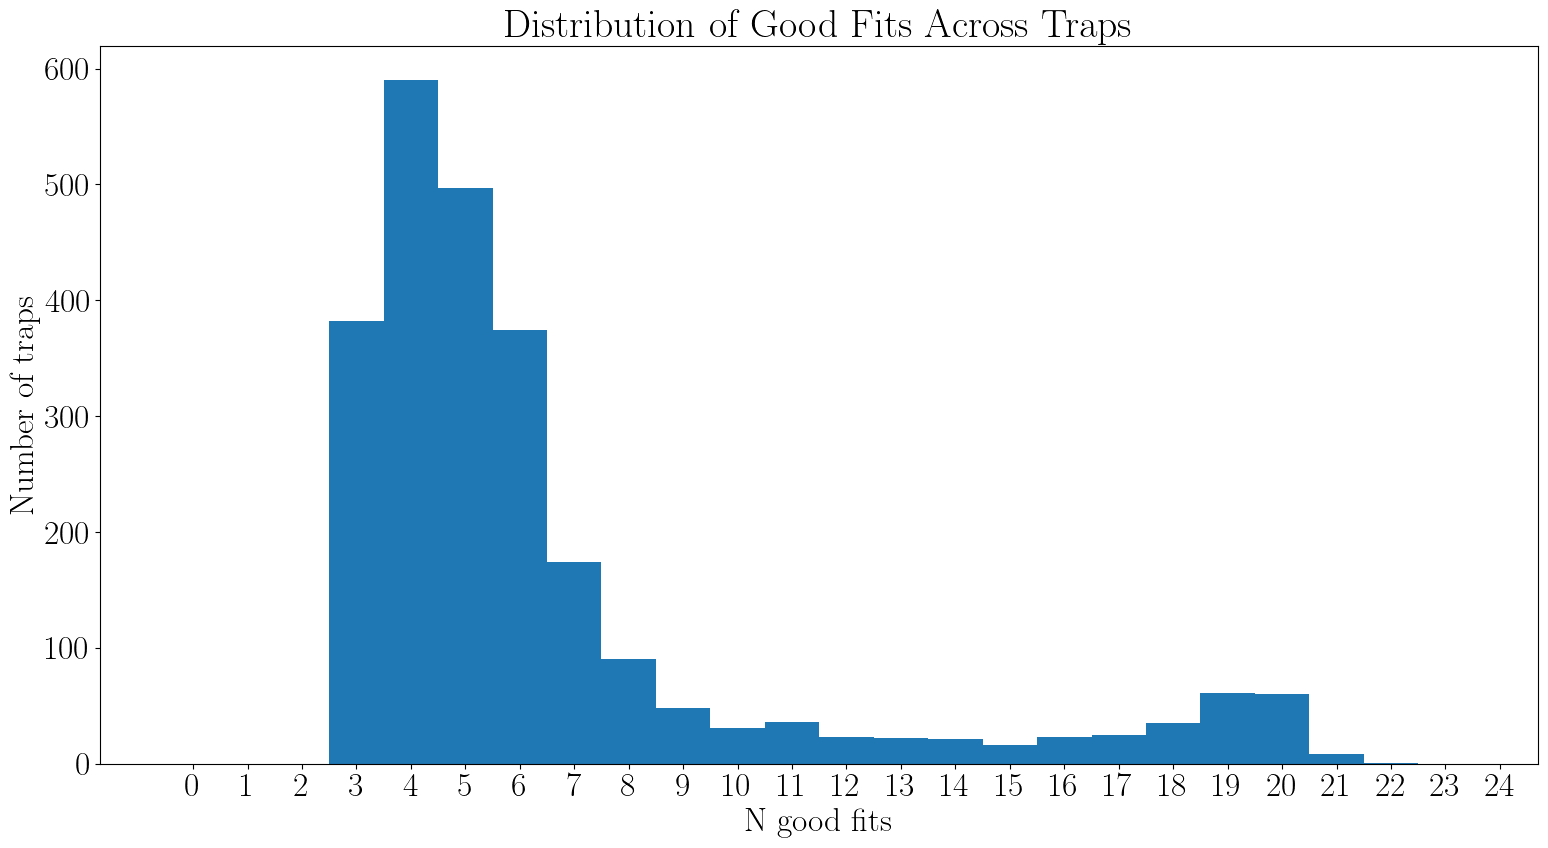

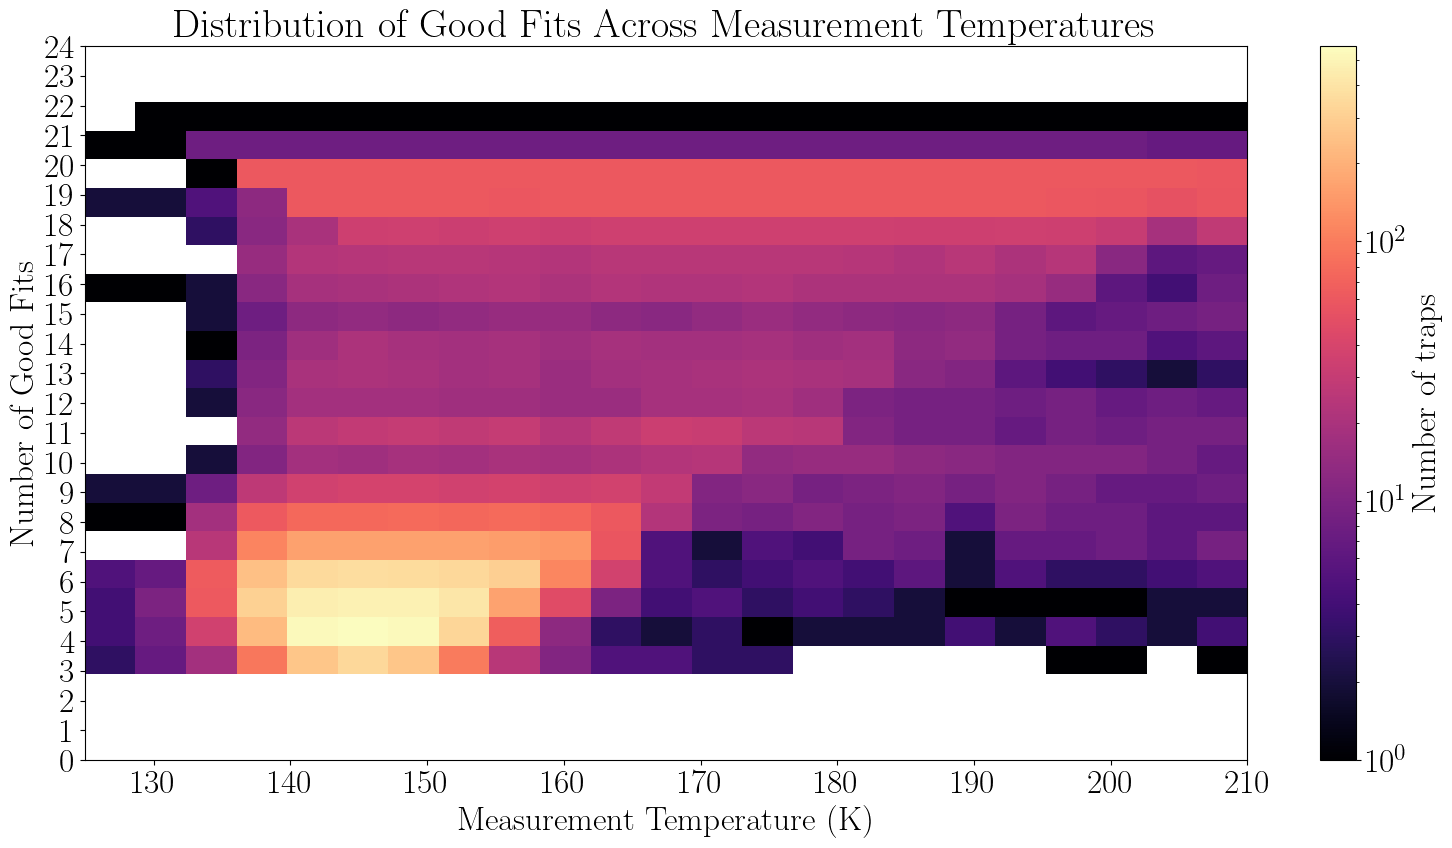

In [6]:
ngood_fits = []
bins = np.arange(0, 25)

count_grid = np.zeros((len(bins),len(measurement_temperatures))) 
mean_measurement_temps_4_good_fits = []
min_measurement_temps_4_good_fits = []
for rec in records_3:
    mtemps = rec['measured_temps']
    ngood_fits.append(len(mtemps))
    if len(mtemps) == 4: mean_measurement_temps_4_good_fits.append(np.mean(mtemps))
    if len(mtemps) == 4: min_measurement_temps_4_good_fits.append(np.min(mtemps))
    for temp in mtemps:
        idx1 = np.where(measurement_temperatures == temp)[0][0]
        idx2 = np.where(len(mtemps) == bins)[0][0]
        count_grid[idx2, idx1] += 1


ngood_fits = np.array(ngood_fits)
count_grid = np.array(count_grid)
# count_grid = count_grid/ np.sum(count_grid, axis=1, keepdims=True)
plt.hist(ngood_fits, bins=bins-0.5, density=False,)
plt.xticks(np.arange(25))
plt.ylabel('Number of traps')
plt.xlabel('N good fits')
plt.title('Distribution of Good Fits Across Traps')
plt.show()
plt.close()

plt.imshow(count_grid, aspect='auto', origin='lower', extent=[measurement_temperatures[0], measurement_temperatures[-1], bins[0], bins[-1]],cmap='magma', norm=colors.LogNorm(vmin=1, vmax=np.max(count_grid)))
plt.colorbar(label='Number of traps')
plt.xlabel('Measurement Temperature (K)')
plt.ylabel('Number of Good Fits')
plt.yticks(bins)
plt.title('Distribution of Good Fits Across Measurement Temperatures')
plt.show()
plt.close()

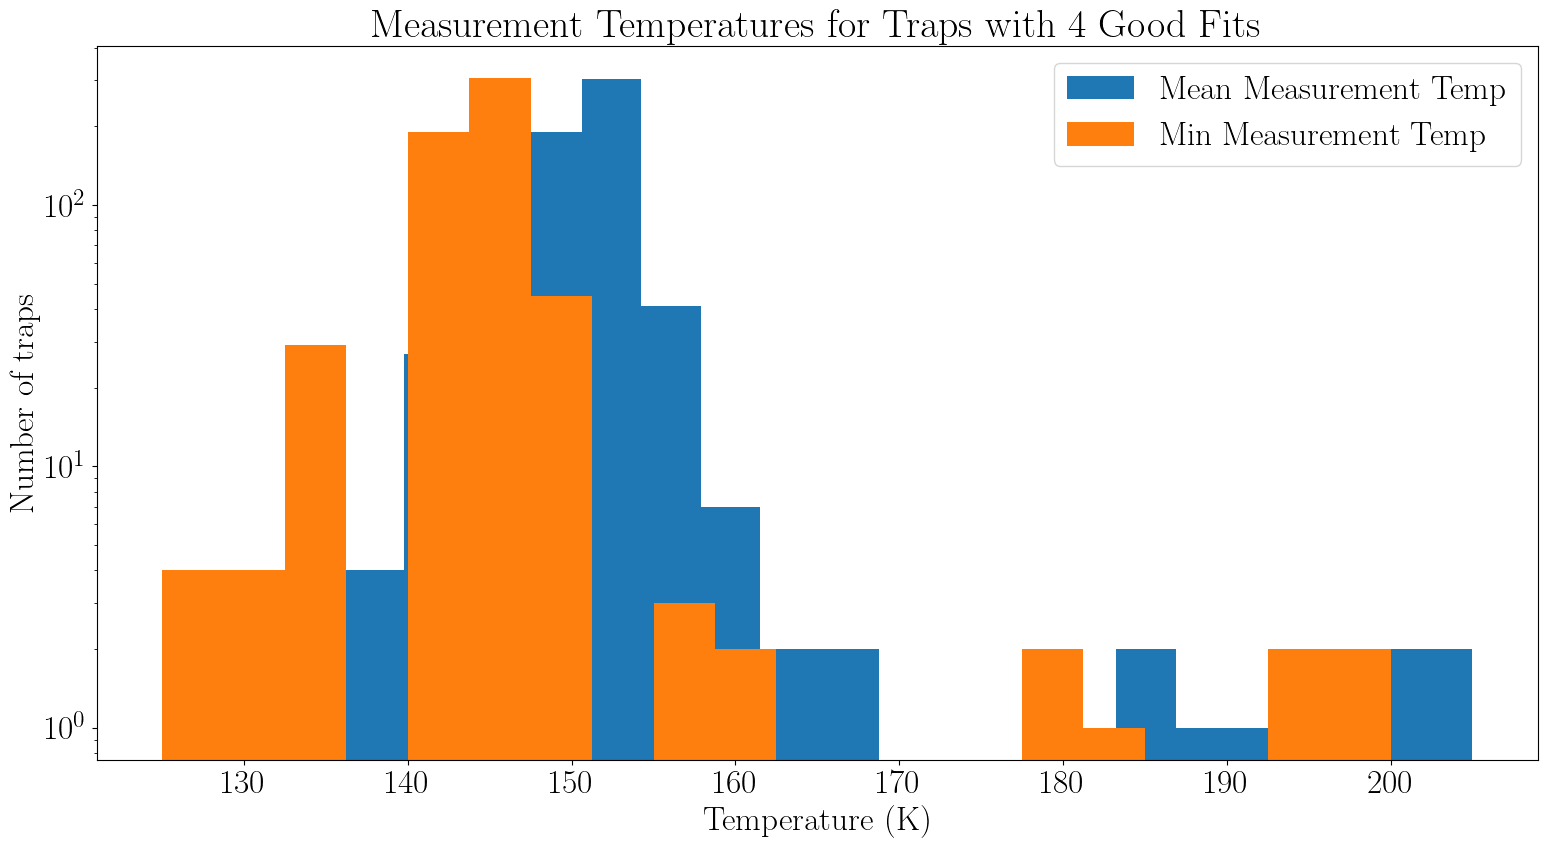

In [7]:
plt.hist(mean_measurement_temps_4_good_fits, bins=20,label='Mean Measurement Temp')
plt.hist(min_measurement_temps_4_good_fits, bins=20,label='Min Measurement Temp')
plt.title('Measurement Temperatures for Traps with 4 Good Fits')
plt.xlabel('Temperature (K)')
plt.ylabel('Number of traps')
plt.yscale('log')
plt.legend()
plt.show()  
plt.close(  )

In [8]:
temp = 175


test_bins = np.geomspace(5e-2,1e2,25)
ngood_cut = 4
def jeffreys_interval(k, n, confidence_level=0.68):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    lo = np.full_like(k, np.nan, dtype=float)
    hi = np.full_like(k, np.nan, dtype=float)
    valid = n > 0
    alpha = 1.0 - confidence_level
    lo[valid] = beta.ppf(alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    hi[valid] = beta.ppf(1.0 - alpha / 2.0, k[valid] + 0.5, n[valid] - k[valid] + 0.5)
    return lo, hi
def wilson_binomial_interval(k, n, cl=0.682689492):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)

    alpha = 1.0 - cl
    z = norm.ppf(1.0 - alpha / 2.0)

    eff = np.full_like(k, np.nan, dtype=float)
    lo = np.full_like(k, np.nan, dtype=float)
    hi = np.full_like(k, np.nan, dtype=float)

    mask = n > 0
    phat = k[mask] / n[mask]

    denom = 1.0 + z**2 / n[mask]
    center = (phat + z**2 / (2.0 * n[mask])) / denom
    half_width = (
        z
        * np.sqrt(phat * (1.0 - phat) / n[mask] + z**2 / (4.0 * n[mask]**2))
        / denom
    )

    eff[mask] = phat
    lo[mask] = np.maximum(0.0, center - half_width)
    hi[mask] = np.minimum(1.0, center + half_width)

    return eff, lo, hi
def calc_eff_hist(measured_hist, extrapolated_hist):
    total_hist = measured_hist + extrapolated_hist

    effhist, eff_lo, eff_hi = wilson_binomial_interval(
        measured_hist,
        total_hist,
        cl=0.682689492,
    )

    eff_yerr = np.vstack([
        np.maximum(0.0, effhist - eff_lo),
        np.maximum(0.0, eff_hi - effhist),
    ])

    return effhist, eff_yerr
all_efficiencies = []

for temp in measurement_temperatures:
    measured = []
    extrapolated = []
    # all = []
    for trap in records_3:
        mtemps = trap['measured_temps']
        if len(mtemps) < ngood_cut: continue
        # all.append(np.exp(log_energy_cross_section(temp, trap['energy'], trap['log_sigma'])))
        if temp in mtemps:
            measured.append(np.exp(log_energy_cross_section(temp, trap['energy'], trap['log_sigma'])))
        else:
            extrapolated.append(np.exp(log_energy_cross_section(temp, trap['energy'], trap['log_sigma'])))

    extrapolated = np.array(extrapolated)
    measured = np.array(measured)    

    measured_hist,mbins =np.histogram(measured, bins=test_bins, density=False)
    extrapolated_hist,ebins = np.histogram(extrapolated, bins=test_bins, density=False)
    measured_hist = measured_hist.astype(float)
    extrapolated_hist = extrapolated_hist.astype(float)
    edges = mbins
    centers = np.sqrt(edges[:-1] * edges[1:])
    xerr = np.vstack([
        centers - edges[:-1],
        edges[1:] - centers,
    ])

    # total_hist = measured_hist+ extrapolated_hist
    fig,ax= plt.subplots(2,sharex=True, gridspec_kw={'height_ratios': [3, 1]}, figsize=(10, 8))
    eff_hist, eff_yerr = calc_eff_hist(measured_hist, extrapolated_hist)
    # eff_hist = np.divide(measured_hist, total_hist, out=np.zeros_like(measured_hist), where=total_hist!=0)

    # plt.stairs(eff_hist,coarse_tau_bins, label='Efficiency', fill=True, edgecolor='black')

    all_efficiencies.append((eff_hist, eff_yerr))

    eff_low = eff_hist - eff_yerr[0]
    # eff_low# eff_low[eff_low < 0] = 0
    # eff_low
    # eff_low_valid = eff_low[eff_low >= 0.5]
    eff_low[eff_low < 0.5] = 0
    eff_low[measured_hist + extrapolated_hist <= 3] = 0


    # print(mbins)
    ax[1].errorbar((mbins[:-1]+mbins[1:])/2, eff_hist, yerr=eff_yerr, xerr=xerr, ls='None', label='Efficiency', marker='o', color='steelblue',capsize=5)
    ax[1].stairs(eff_low, edges, label='Lower Eff Bound', fill=True, edgecolor='black', alpha=0.5,color='firebrick')
    ax[0].hist(extrapolated, bins=coarse_tau_bins, alpha=0.5, label='Extrapolated', density=False, edgecolor='black')
    ax[0].hist(measured, bins=coarse_tau_bins, alpha=0.5, label='Measured', density=False, edgecolor='black')
    # # plt.hist(all, bins=coarse_tau_bins, alpha=0.5, label='All', density=False, edgecolor='black')
    ax[1].set_xscale('log')
    ax[1].set_xlabel(rf'$\tau_e(T)$ at {temp}K [s]')
    ax[0].set_ylabel('Number of traps')
    ax[0].set_yscale('log')
    # plt.title(rf'Comparison of Measured vs Extrapolated $\tau$ at {temp}K')
    ax[0].legend()
    ax[1].set_ylabel('Efficiency')
    ax[1].set_xlim(1e-7, 1e8)
    # plt.show()
    plt.close()



190
Longest region with eff > 0.8: 6 bins
  conservative bounds      : 1.187 -- 4.213
  efficiencies in region   : [1.         1.         1.         0.83333333 1.         1.        ]


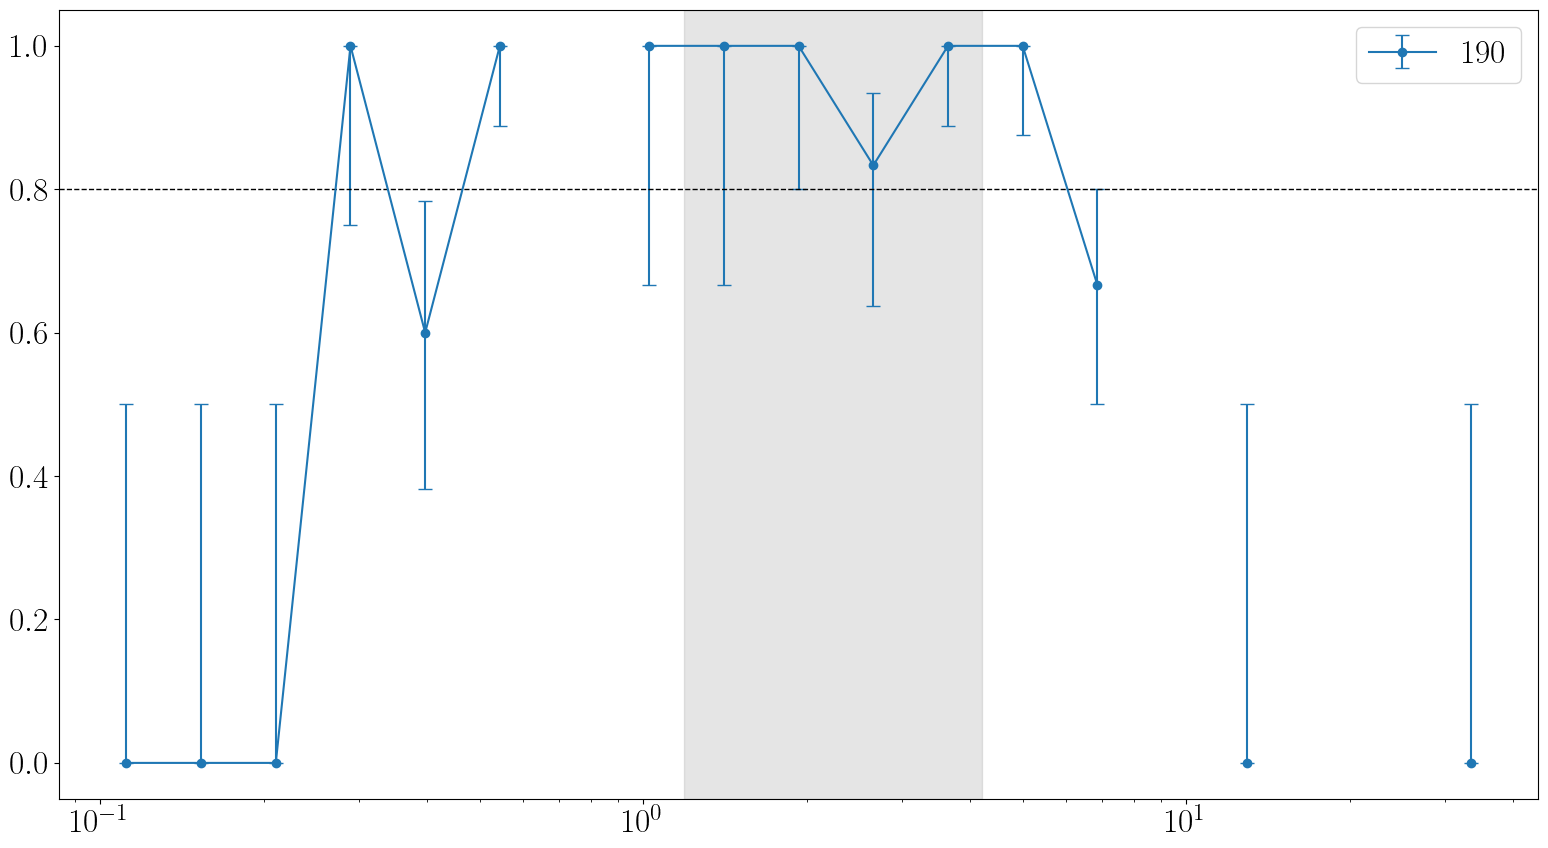

In [9]:
def longest_true_run(mask):
    """Return (start, stop) inclusive index bounds of the longest run of True in mask.
    Returns None if there are no True values."""
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return None
    # indices where the value changes; pad with False on both ends
    padded = np.concatenate(([False], mask, [False]))
    diff = np.diff(padded.astype(int))
    run_starts = np.where(diff == 1)[0]          # first True index of each run
    run_stops = np.where(diff == -1)[0] - 1      # last True index of each run
    lengths = run_stops - run_starts + 1
    i = np.argmax(lengths)
    return run_starts[i], run_stops[i]


threshold = 0.8

test_temps = [140,150,160,170,180,190,200]
test_temps = [190]
for e,eff in enumerate(all_efficiencies):
    temp = measurement_temperatures[e]
    if temp not in test_temps: continue
    centers =(mbins[:-1]+mbins[1:])/2
    temp_eff = eff[0]
    temp_eff_err = eff[1]
    cut = centers > 1e-1
    temp_eff = temp_eff[cut]

    temp_eff_err = temp_eff_err[:,cut]
    cut_centers= centers[cut]
    cut_left_edges = mbins[:-1][cut]
    cut_right_edges = mbins[1:][cut]

    print(temp)
    run = longest_true_run(temp_eff > threshold)
    if run is None:
        print(f'No region with efficiency > {threshold}')
    else:
        lo, hi = run
        # conservative bounds: right edge of the lowest bin, left edge of the highest bin
        left, right = cut_right_edges[lo], cut_left_edges[hi]
        print(f'Longest region with eff > {threshold}: {hi - lo + 1} bins')
        print(f'  conservative bounds      : {left:.4g} -- {right:.4g}')
        print(f'  efficiencies in region   : {temp_eff[lo:hi+1]}')
        plt.axvspan(left, right, color='grey', alpha=0.2)

    plt.errorbar(cut_centers,temp_eff,yerr=temp_eff_err,label=measurement_temperatures[e],marker='o',capsize=5)
plt.axhline(threshold, ls='--', color='k', lw=1)
plt.xscale('log')
plt.legend()
plt.show()

## Bounding 135 K traps from the good-efficiency window

Pick a measurement temperature with a stable high-efficiency $\tau$ region, select the
characterized traps whose $\tau(T)$ lands inside that region, and project them to 135 K.

The bound at 135 K is the **direct per-trap range**: evaluate $\tau(135\,\mathrm{K})$ for every
selected trap and take min/max. Each trap contributes the $\tau$ implied by its own fitted
$(E,\log\sigma)$ pair, so the strong E$-\log\sigma$ correlation is respected exactly and no
unphysical parameter combinations enter.

In [16]:
measurement_temperatures

array([125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 183,
       185, 187, 190, 193, 195, 197, 200, 203, 207, 210])

Good-efficiency window at 140 K (eff > 0.8):
  selection range (outer edges) : 0.0942 -- 0.3344 s  (4 bins)
  conservative inner edges      : 0.1293 -- 0.2436 s
  traps selected                : 23

Selected-trap parameter ranges:
  E         : 0.0855 -- 0.3314 eV
  log_sigma : -51.1929 -- -30.8958

tau bounds at 135 K (direct per-trap range):
  0.2126 -- 0.848 s


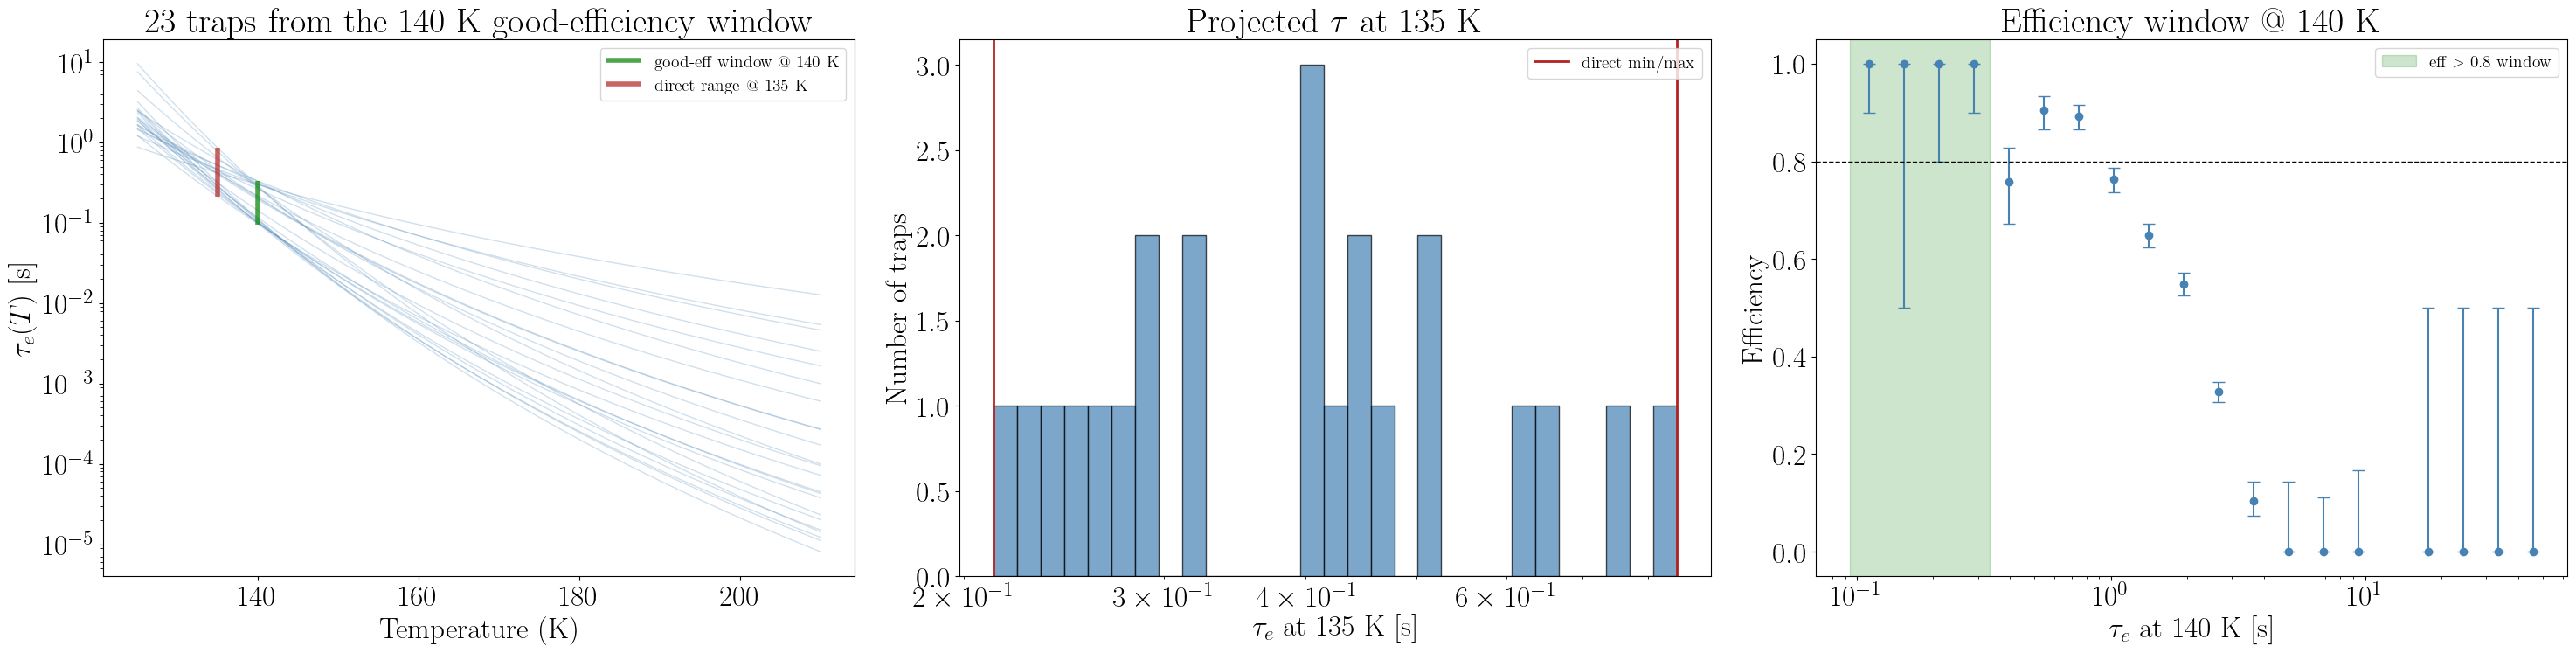

Good-efficiency window at 145 K (eff > 0.8):
  selection range (outer edges) : 0.0942 -- 1.187 s  (8 bins)
  conservative inner edges      : 0.1293 -- 0.8647 s
  traps selected                : 1975

Selected-trap parameter ranges:
  E         : 0.0456 -- 0.3911 eV
  log_sigma : -54.9431 -- -27.7743

tau bounds at 135 K (direct per-trap range):
  0.3967 -- 10.83 s


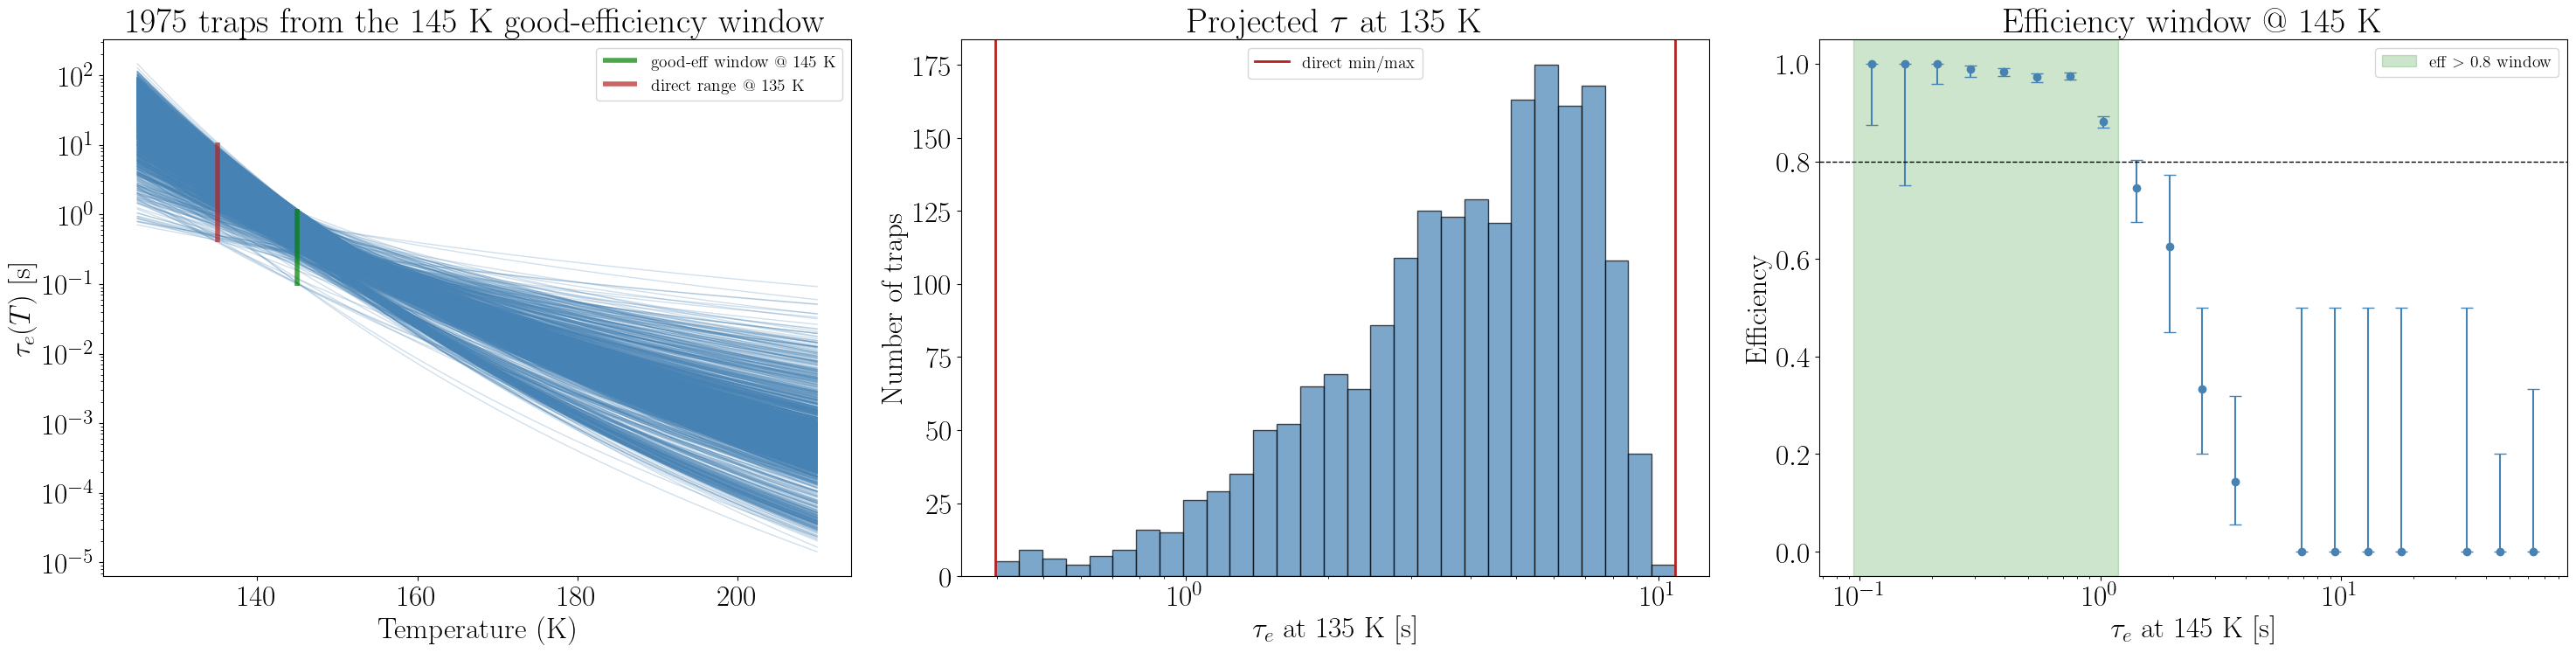

Good-efficiency window at 150 K (eff > 0.8):
  selection range (outer edges) : 0.0942 -- 3.069 s  (11 bins)
  conservative inner edges      : 0.1293 -- 2.236 s
  traps selected                : 2037

Selected-trap parameter ranges:
  E         : 0.0456 -- 0.3911 eV
  log_sigma : -54.9431 -- -27.7743

tau bounds at 135 K (direct per-trap range):
  0.4172 -- 52.95 s


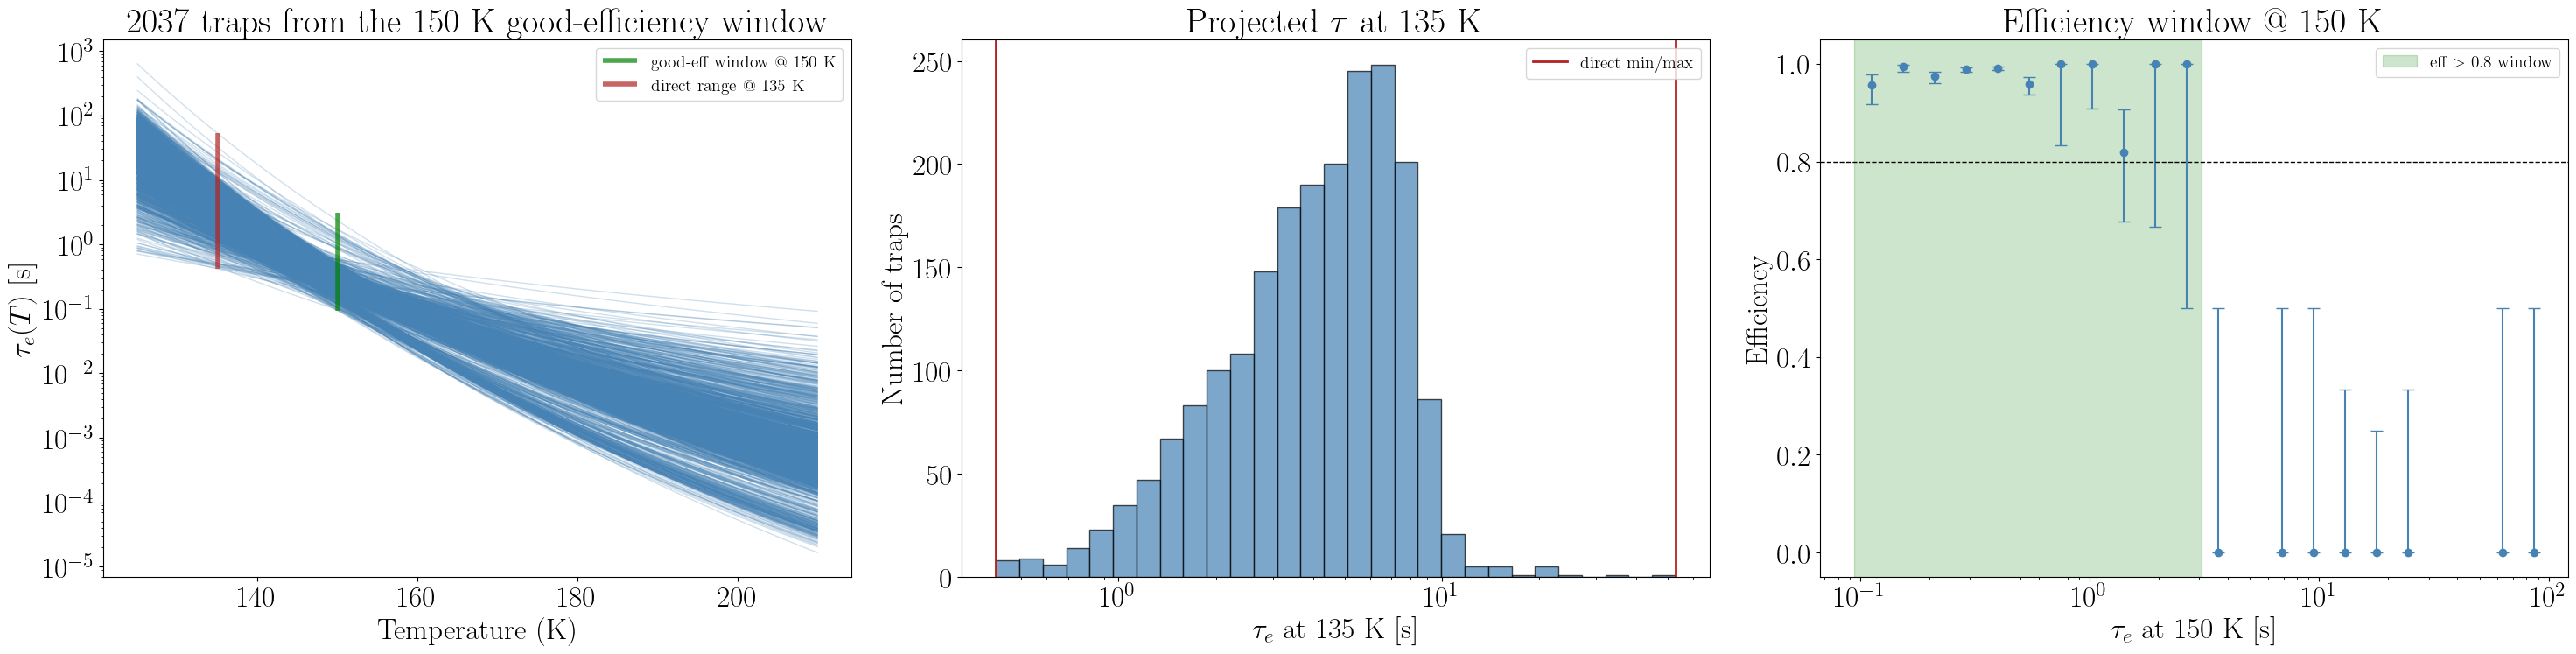

Good-efficiency window at 155 K (eff > 0.8):
  selection range (outer edges) : 0.0942 -- 1.629 s  (9 bins)
  conservative inner edges      : 0.1293 -- 1.187 s
  traps selected                : 1802

Selected-trap parameter ranges:
  E         : 0.0456 -- 0.3616 eV
  log_sigma : -54.9431 -- -31.0546

tau bounds at 135 K (direct per-trap range):
  0.4172 -- 74.77 s


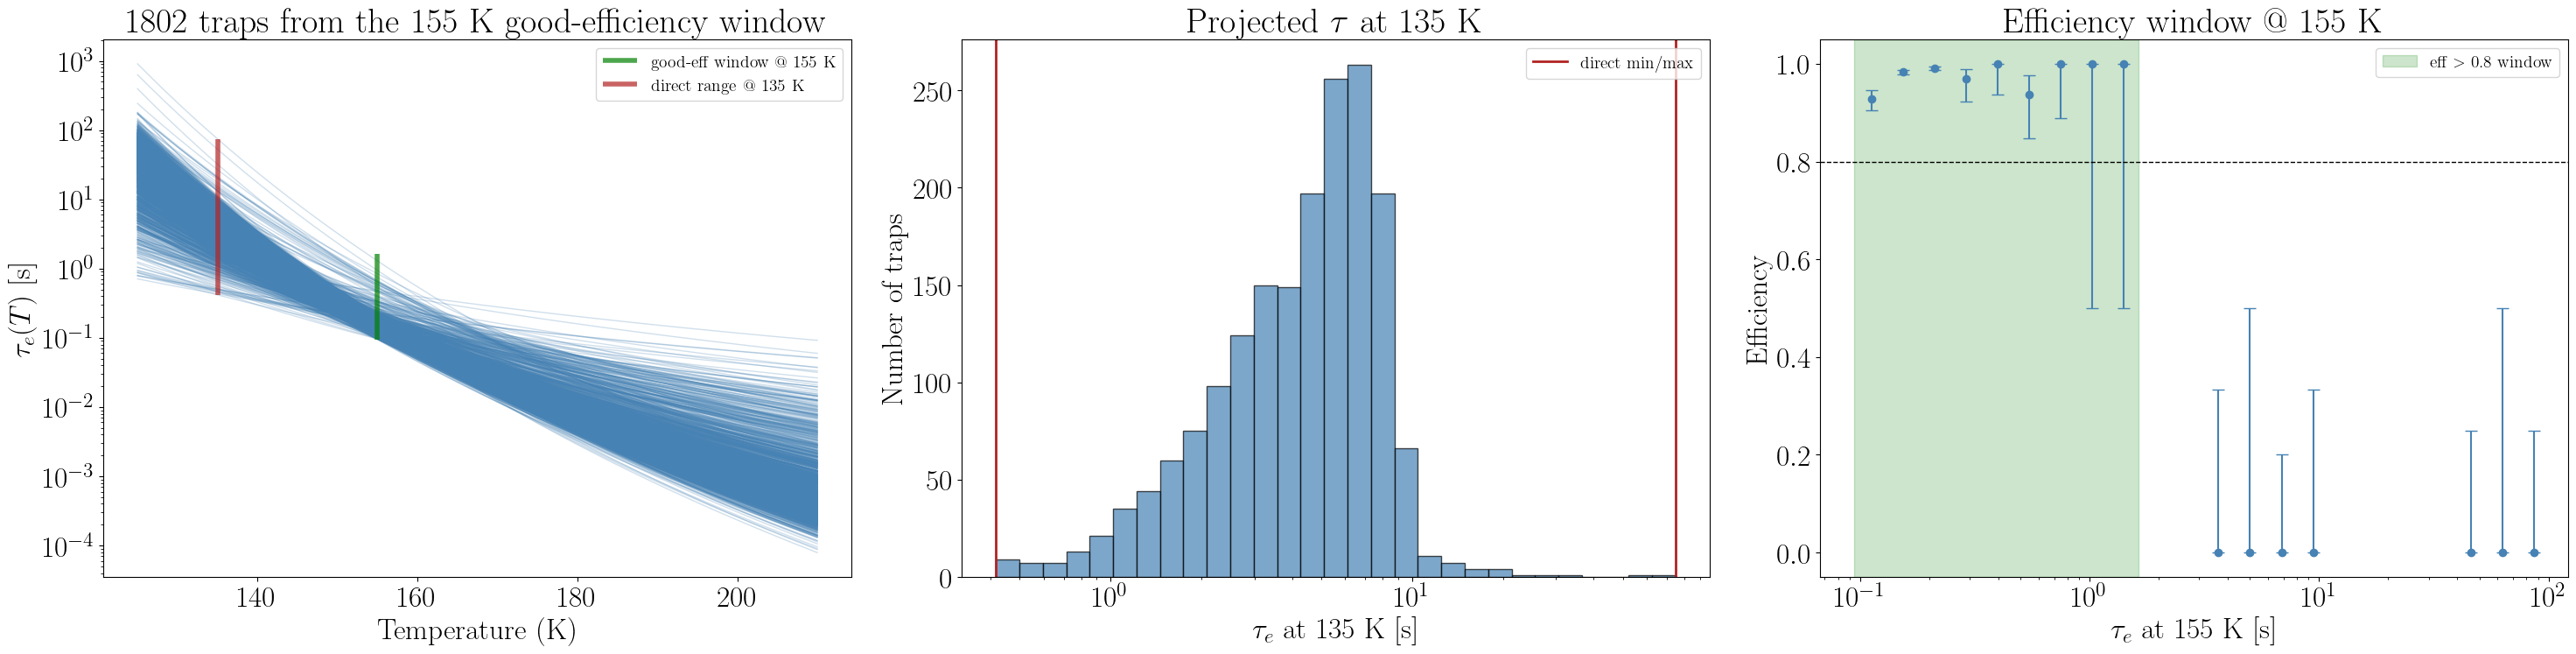

Good-efficiency window at 160 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.3344 s  (2 bins)
  conservative inner edges      : 0.2436 -- 0.2436 s
  traps selected                : 55

Selected-trap parameter ranges:
  E         : 0.0456 -- 0.3446 eV
  log_sigma : -54.7866 -- -33.4108

tau bounds at 135 K (direct per-trap range):
  0.497 -- 32.28 s


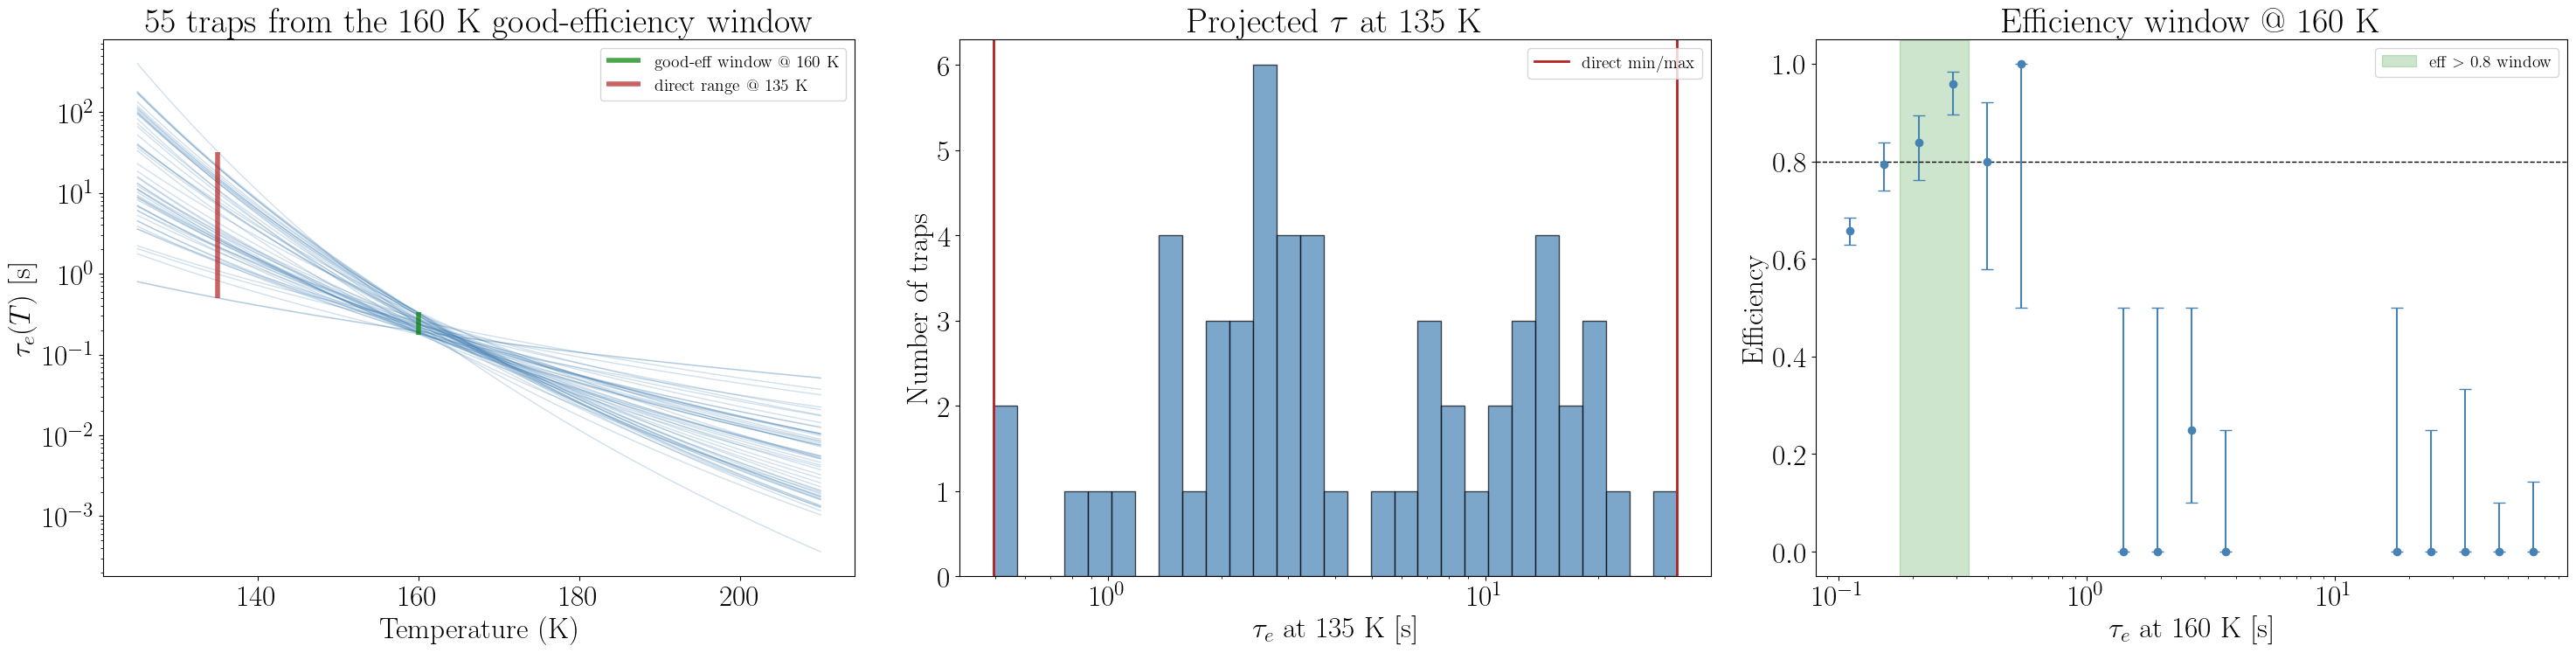

Good-efficiency window at 165 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.3344 s  (2 bins)
  conservative inner edges      : 0.2436 -- 0.2436 s
  traps selected                : 10

Selected-trap parameter ranges:
  E         : 0.0533 -- 0.3430 eV
  log_sigma : -54.9431 -- -34.2590

tau bounds at 135 K (direct per-trap range):
  0.9888 -- 74.77 s


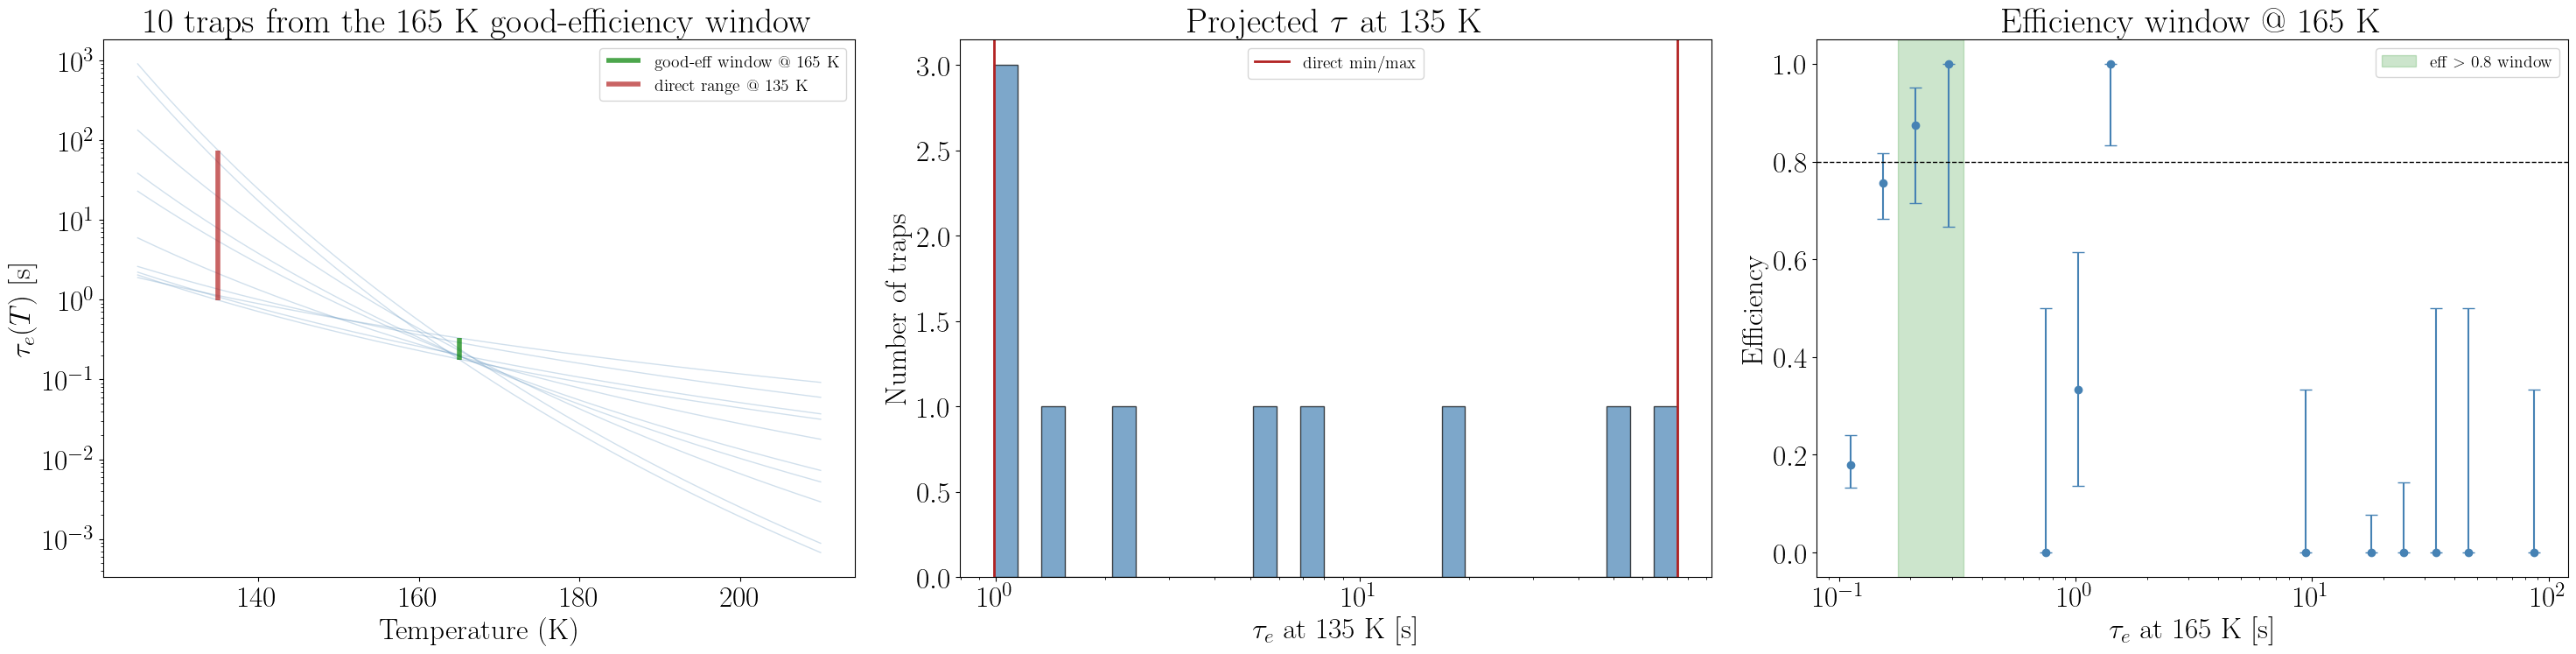

Good-efficiency window at 170 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.3344 s  (2 bins)
  conservative inner edges      : 0.2436 -- 0.2436 s
  traps selected                : 2

Selected-trap parameter ranges:
  E         : 0.0533 -- 0.0734 eV
  log_sigma : -54.9431 -- -53.4067

tau bounds at 135 K (direct per-trap range):
  1.131 -- 1.358 s


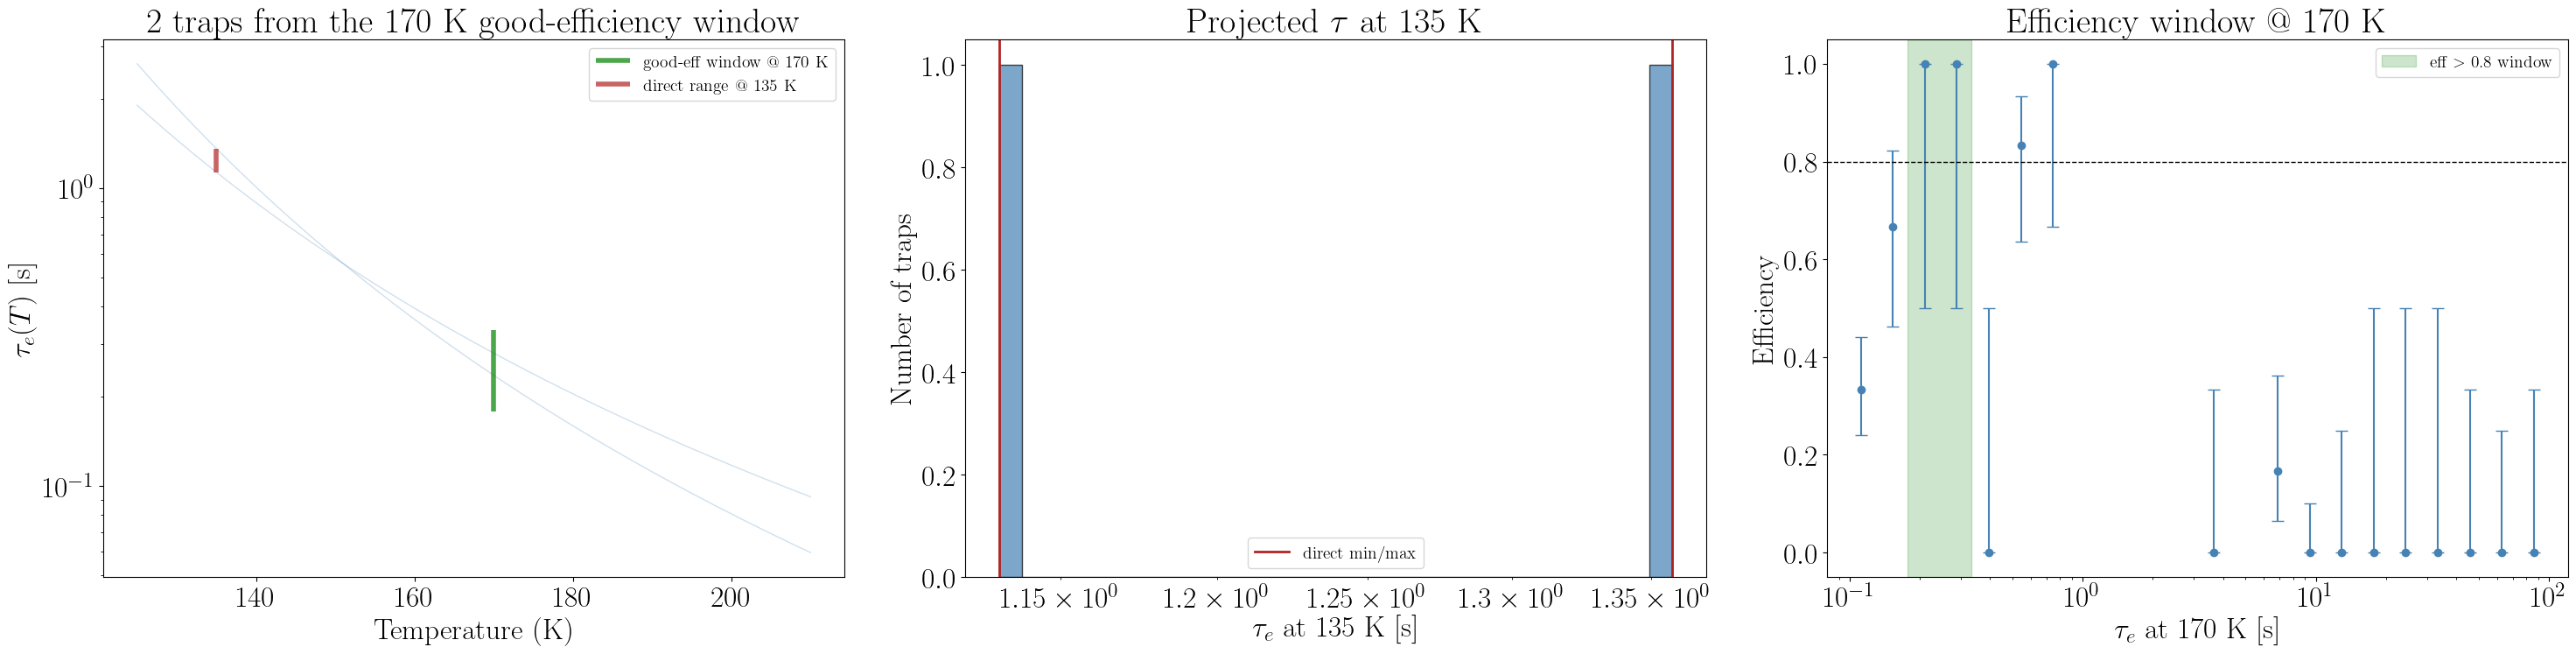

Good-efficiency window at 175 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.3344 s  (2 bins)
  conservative inner edges      : 0.2436 -- 0.2436 s
  traps selected                : 11

Selected-trap parameter ranges:
  E         : 0.0533 -- 0.3670 eV
  log_sigma : -54.9431 -- -34.5698

tau bounds at 135 K (direct per-trap range):
  1.131 -- 695.4 s


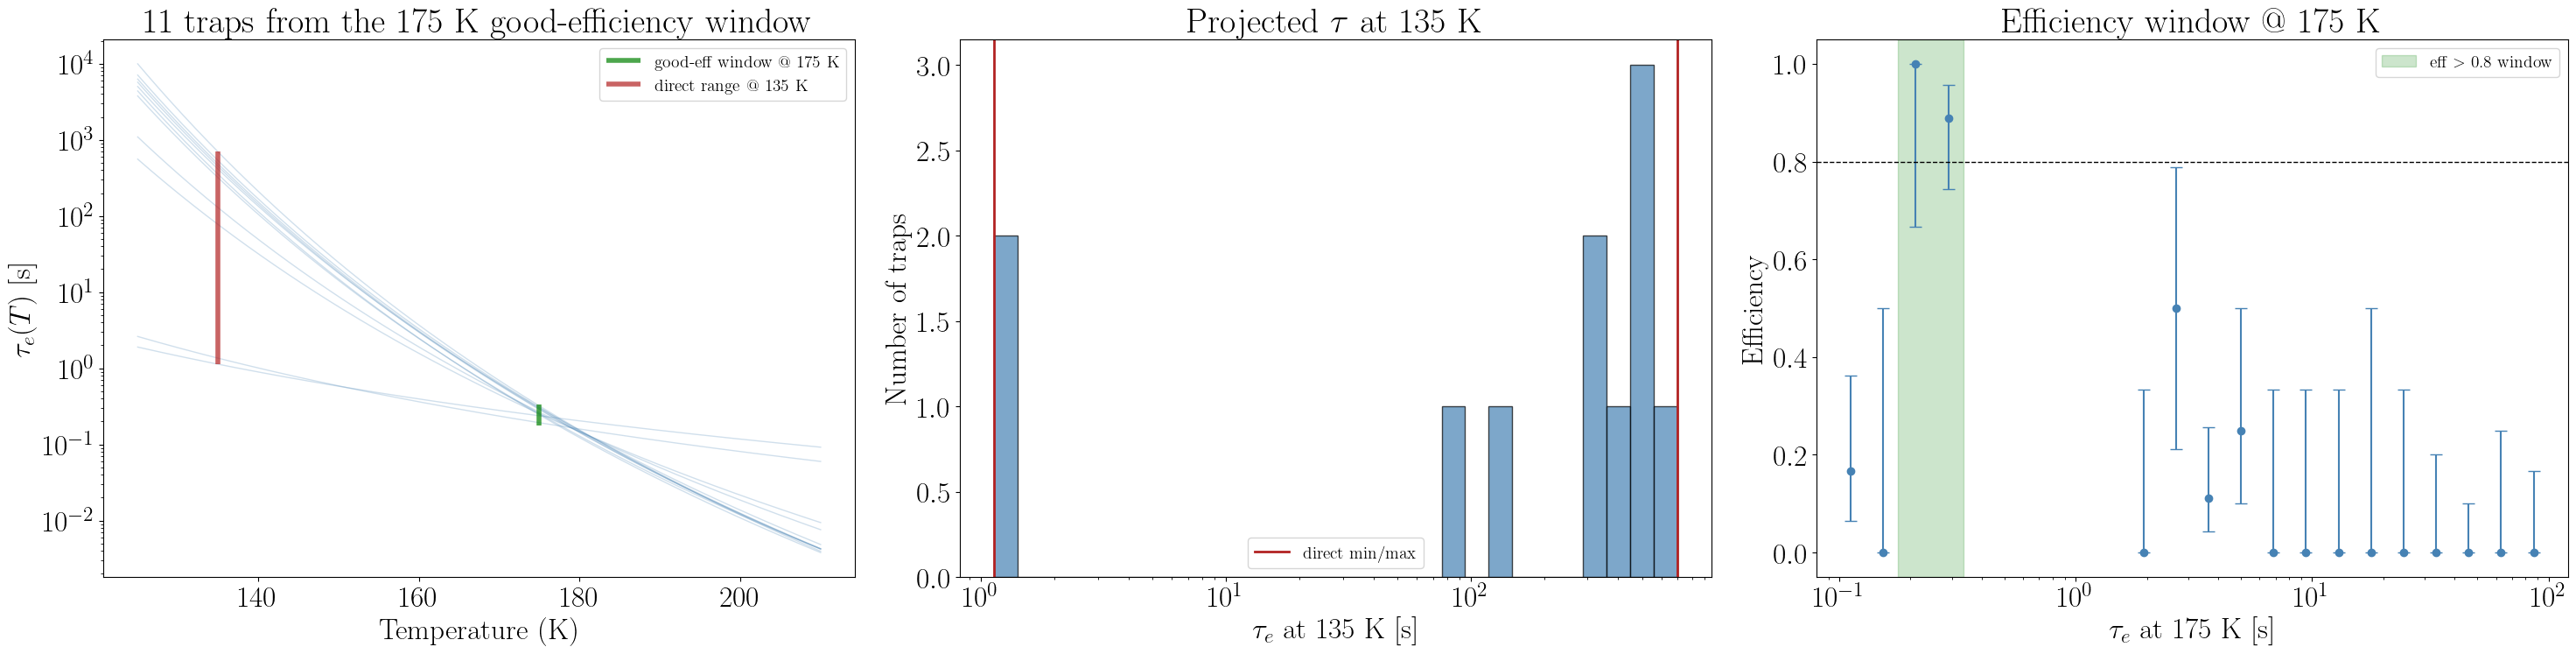

Good-efficiency window at 180 K (eff > 0.8):
  selection range (outer edges) : 1.187 -- 2.236 s  (2 bins)
  conservative inner edges      : 1.629 -- 1.629 s
  traps selected                : 14

Selected-trap parameter ranges:
  E         : 0.3458 -- 0.4273 eV
  log_sigma : -38.4276 -- -32.7540

tau bounds at 135 K (direct per-trap range):
  5227 -- 2.019e+04 s


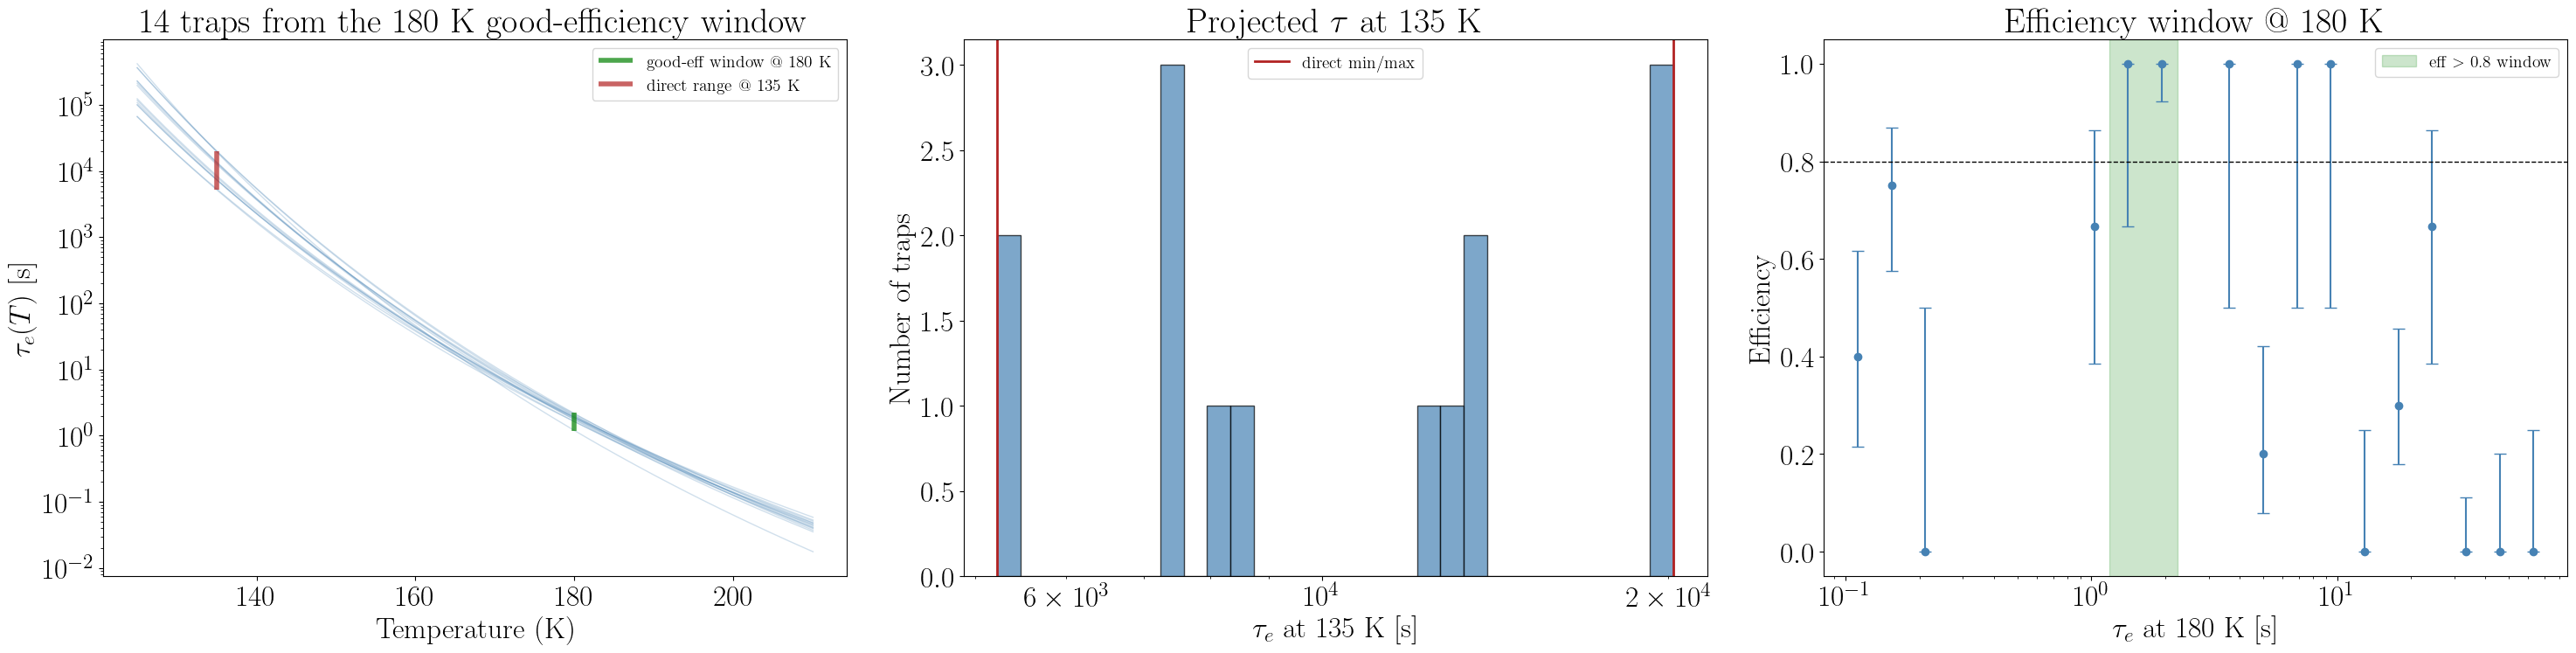

Good-efficiency window at 183 K (eff > 0.8):
  selection range (outer edges) : 0.63 -- 1.629 s  (3 bins)
  conservative inner edges      : 0.8647 -- 1.187 s
  traps selected                : 16

Selected-trap parameter ranges:
  E         : 0.3278 -- 0.4367 eV
  log_sigma : -39.0300 -- -32.0952

tau bounds at 135 K (direct per-trap range):
  2123 -- 2.253e+04 s


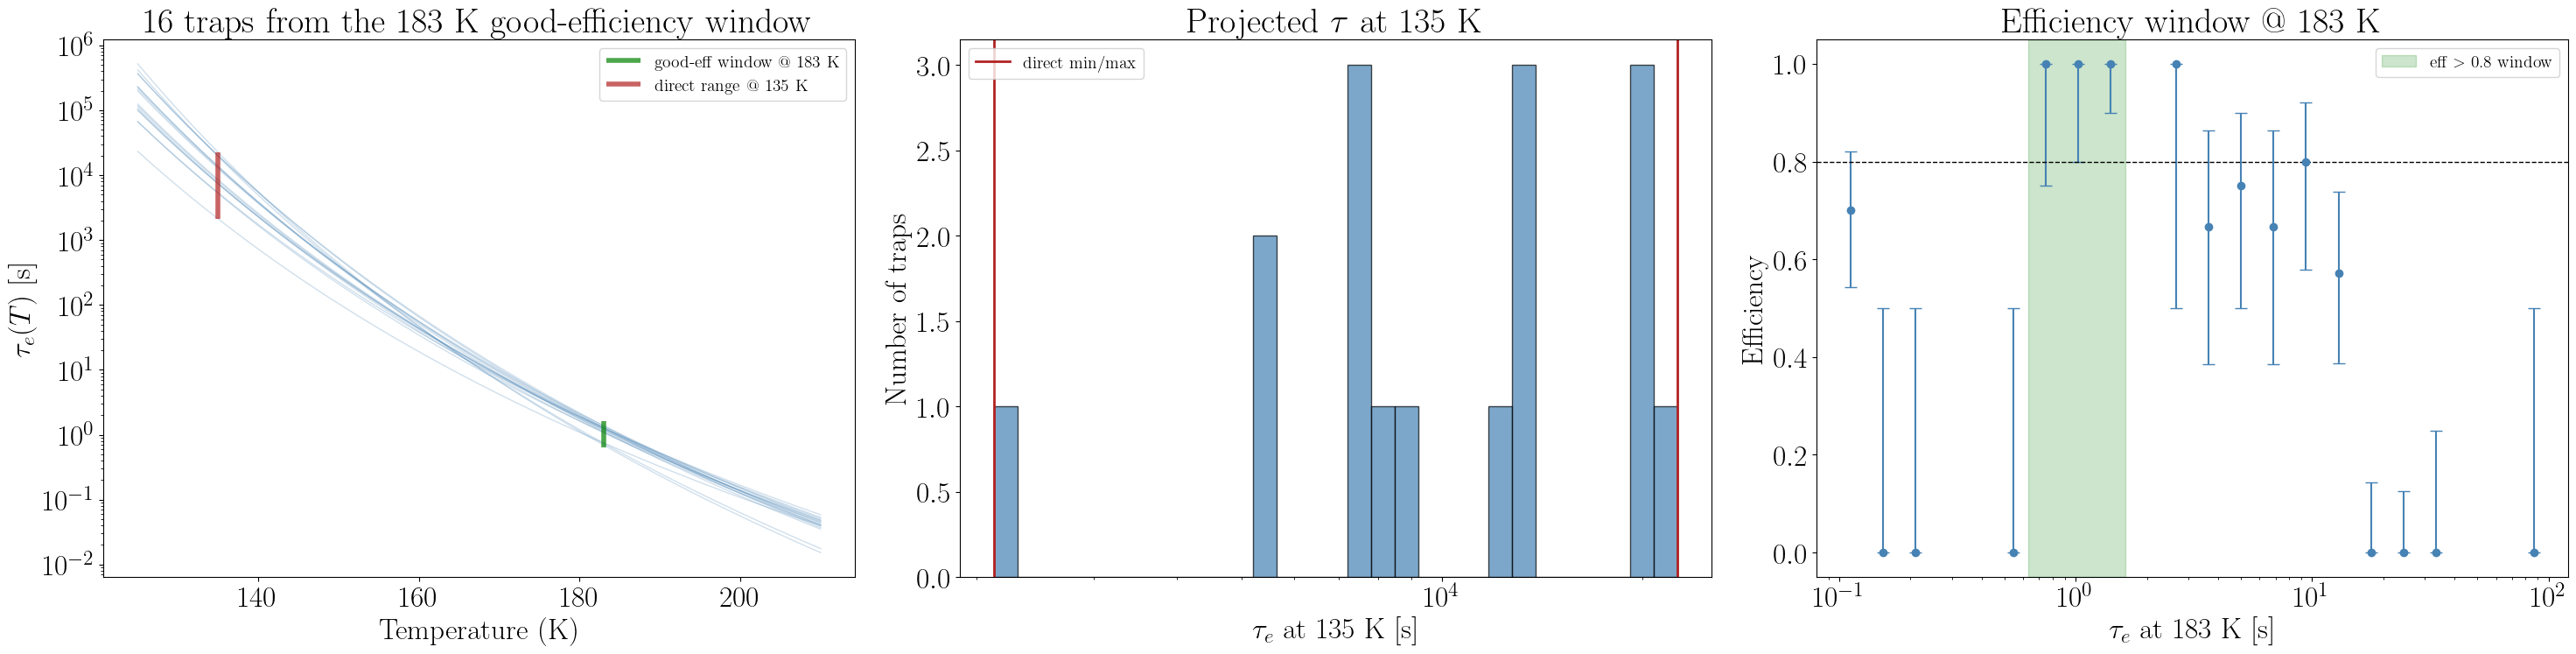

Good-efficiency window at 185 K (eff > 0.8):
  selection range (outer edges) : 0.459 -- 1.187 s  (3 bins)
  conservative inner edges      : 0.63 -- 0.8647 s
  traps selected                : 17

Selected-trap parameter ranges:
  E         : 0.3278 -- 0.4367 eV
  log_sigma : -39.0300 -- -32.0952

tau bounds at 135 K (direct per-trap range):
  2123 -- 2.253e+04 s


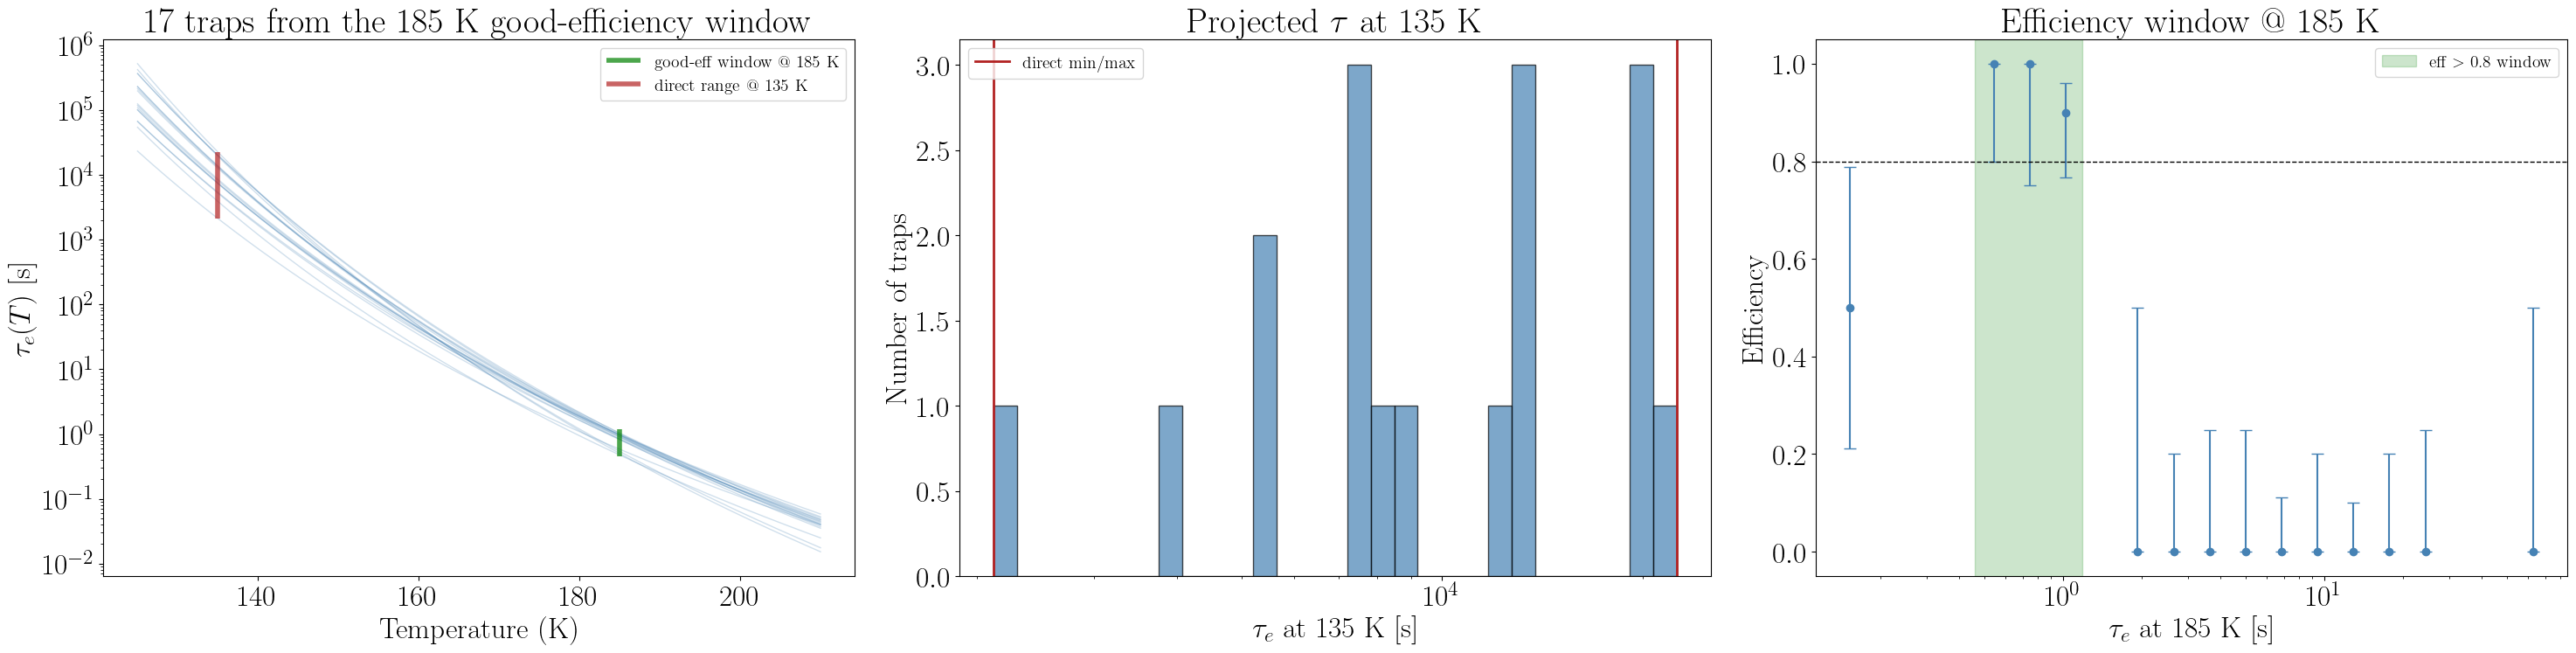

Good-efficiency window at 187 K (eff > 0.8):
  selection range (outer edges) : 1.187 -- 7.937 s  (6 bins)
  conservative inner edges      : 1.629 -- 5.782 s
  traps selected                : 22

Selected-trap parameter ranges:
  E         : 0.1677 -- 0.5801 eV
  log_sigma : -50.9352 -- -25.5789

tau bounds at 135 K (direct per-trap range):
  361.1 -- 6.994e+06 s


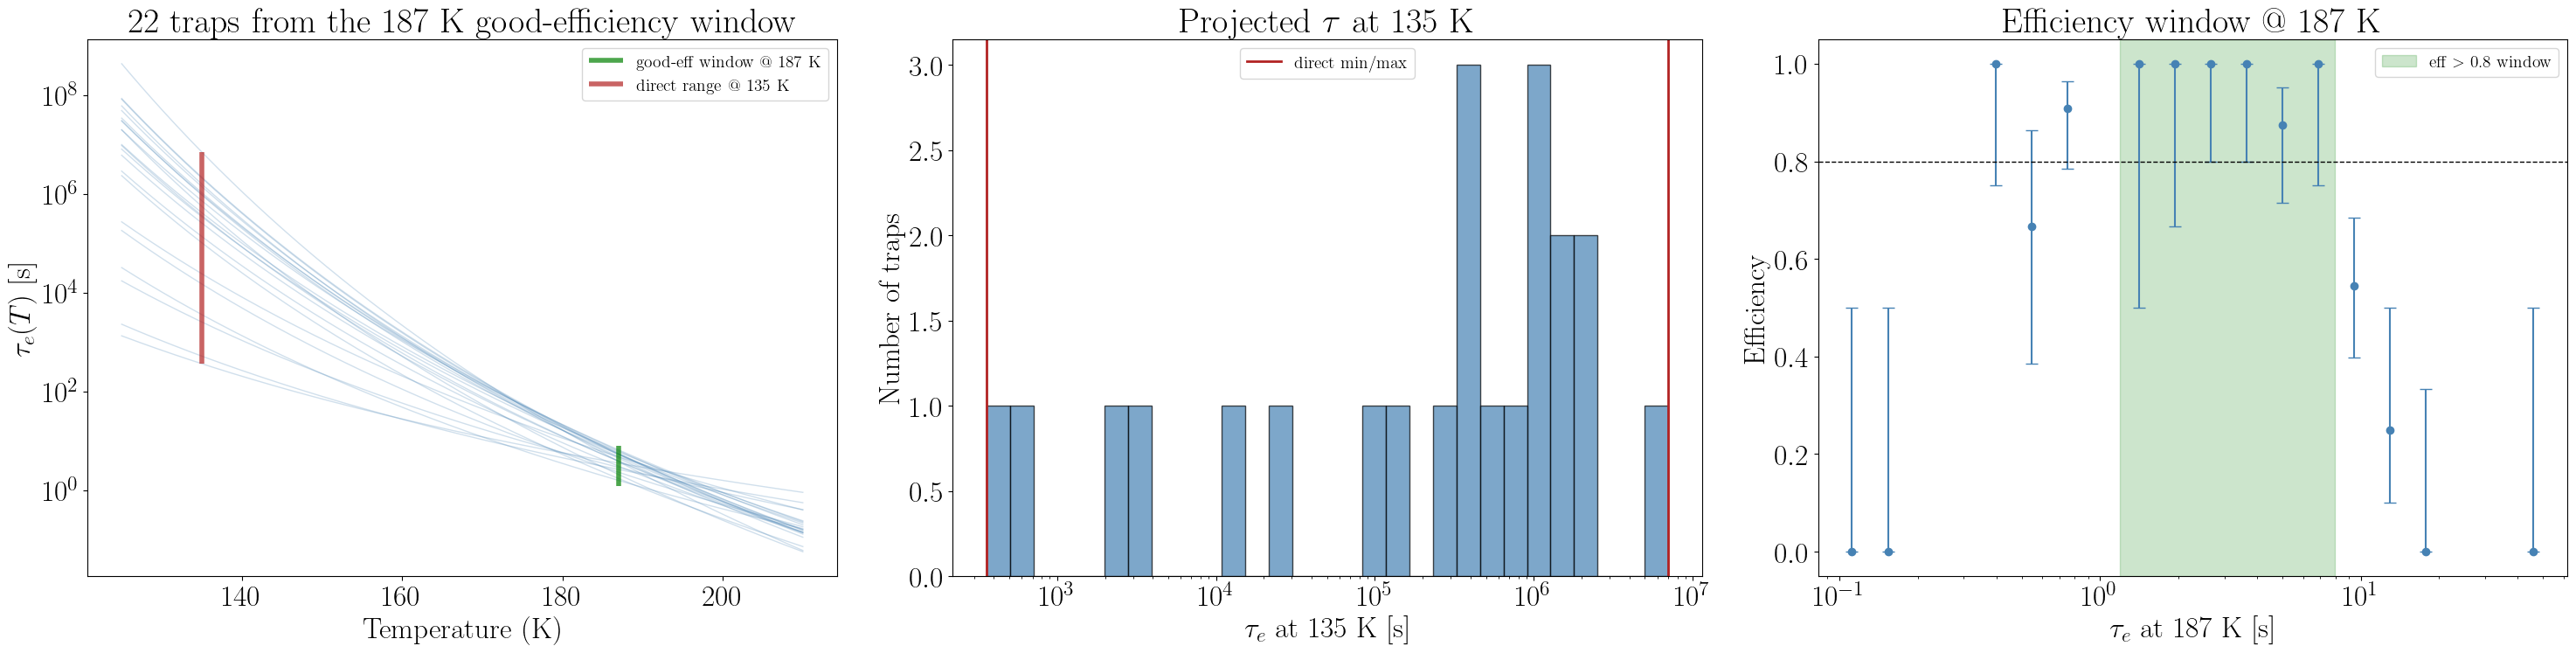

Good-efficiency window at 190 K (eff > 0.8):
  selection range (outer edges) : 0.8647 -- 5.782 s  (6 bins)
  conservative inner edges      : 1.187 -- 4.213 s
  traps selected                : 29

Selected-trap parameter ranges:
  E         : 0.1677 -- 0.5801 eV
  log_sigma : -50.9352 -- -25.5789

tau bounds at 135 K (direct per-trap range):
  361.1 -- 9.672e+06 s


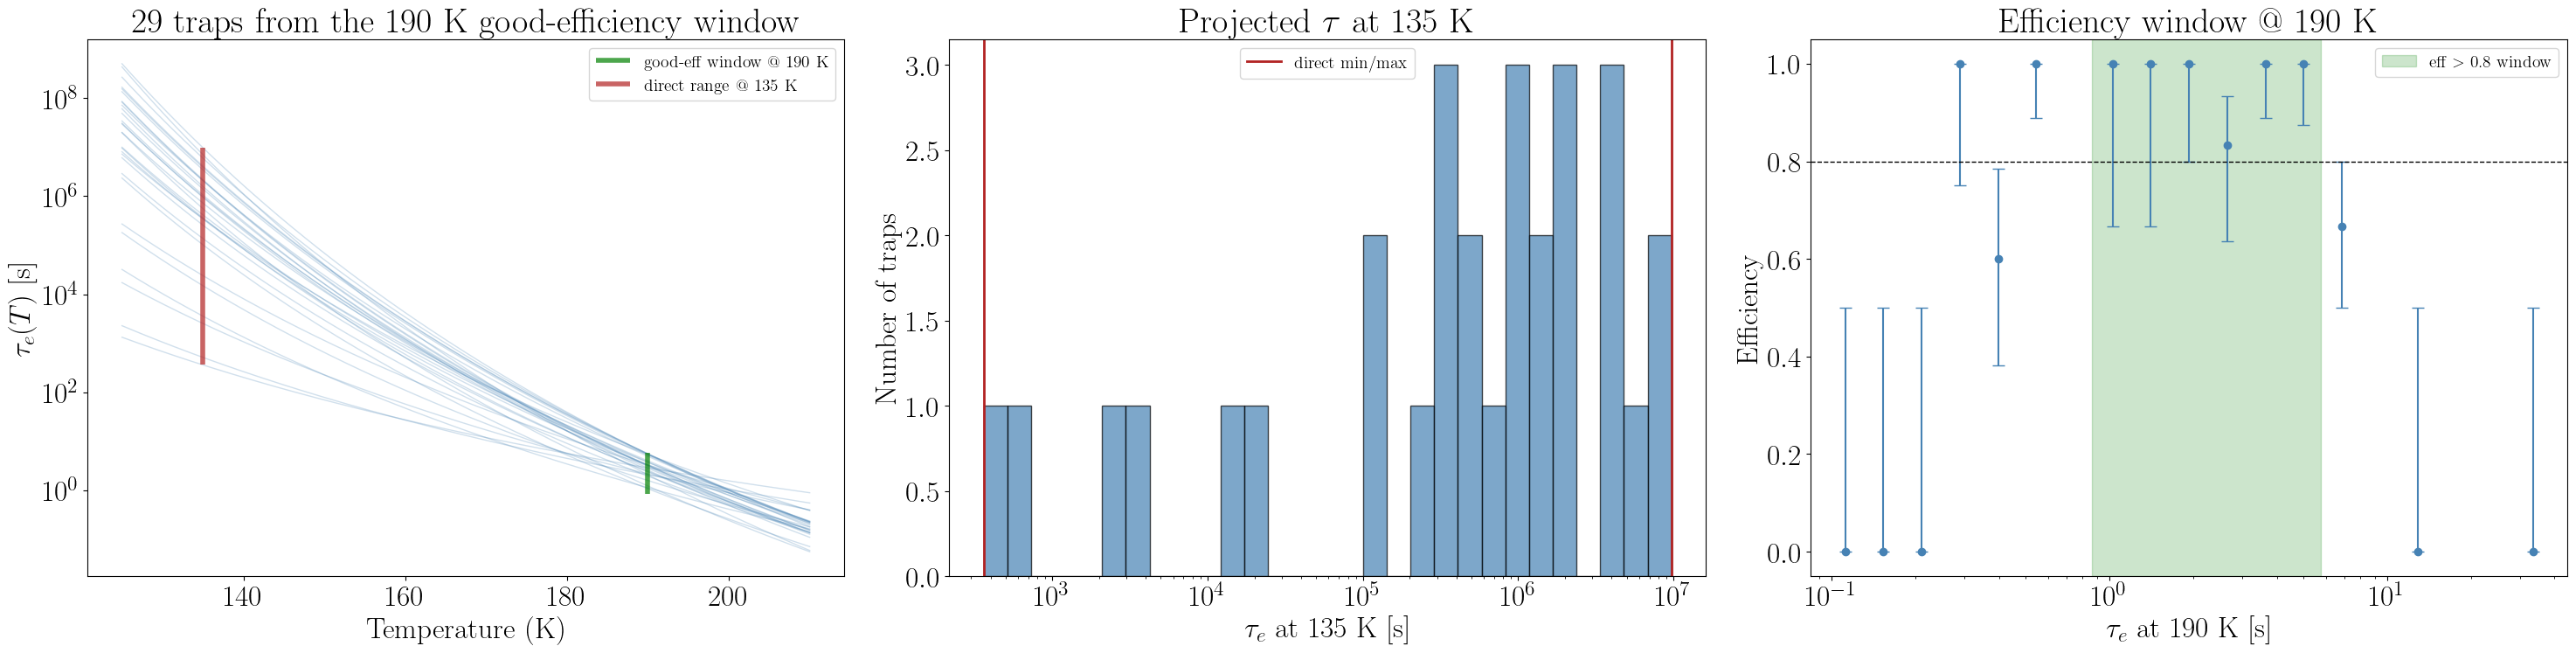

Good-efficiency window at 193 K (eff > 0.8):
  selection range (outer edges) : 0.8647 -- 4.213 s  (5 bins)
  conservative inner edges      : 1.187 -- 3.069 s
  traps selected                : 32

Selected-trap parameter ranges:
  E         : 0.1677 -- 0.6177 eV
  log_sigma : -50.9352 -- -24.5930

tau bounds at 135 K (direct per-trap range):
  361.1 -- 6.457e+07 s


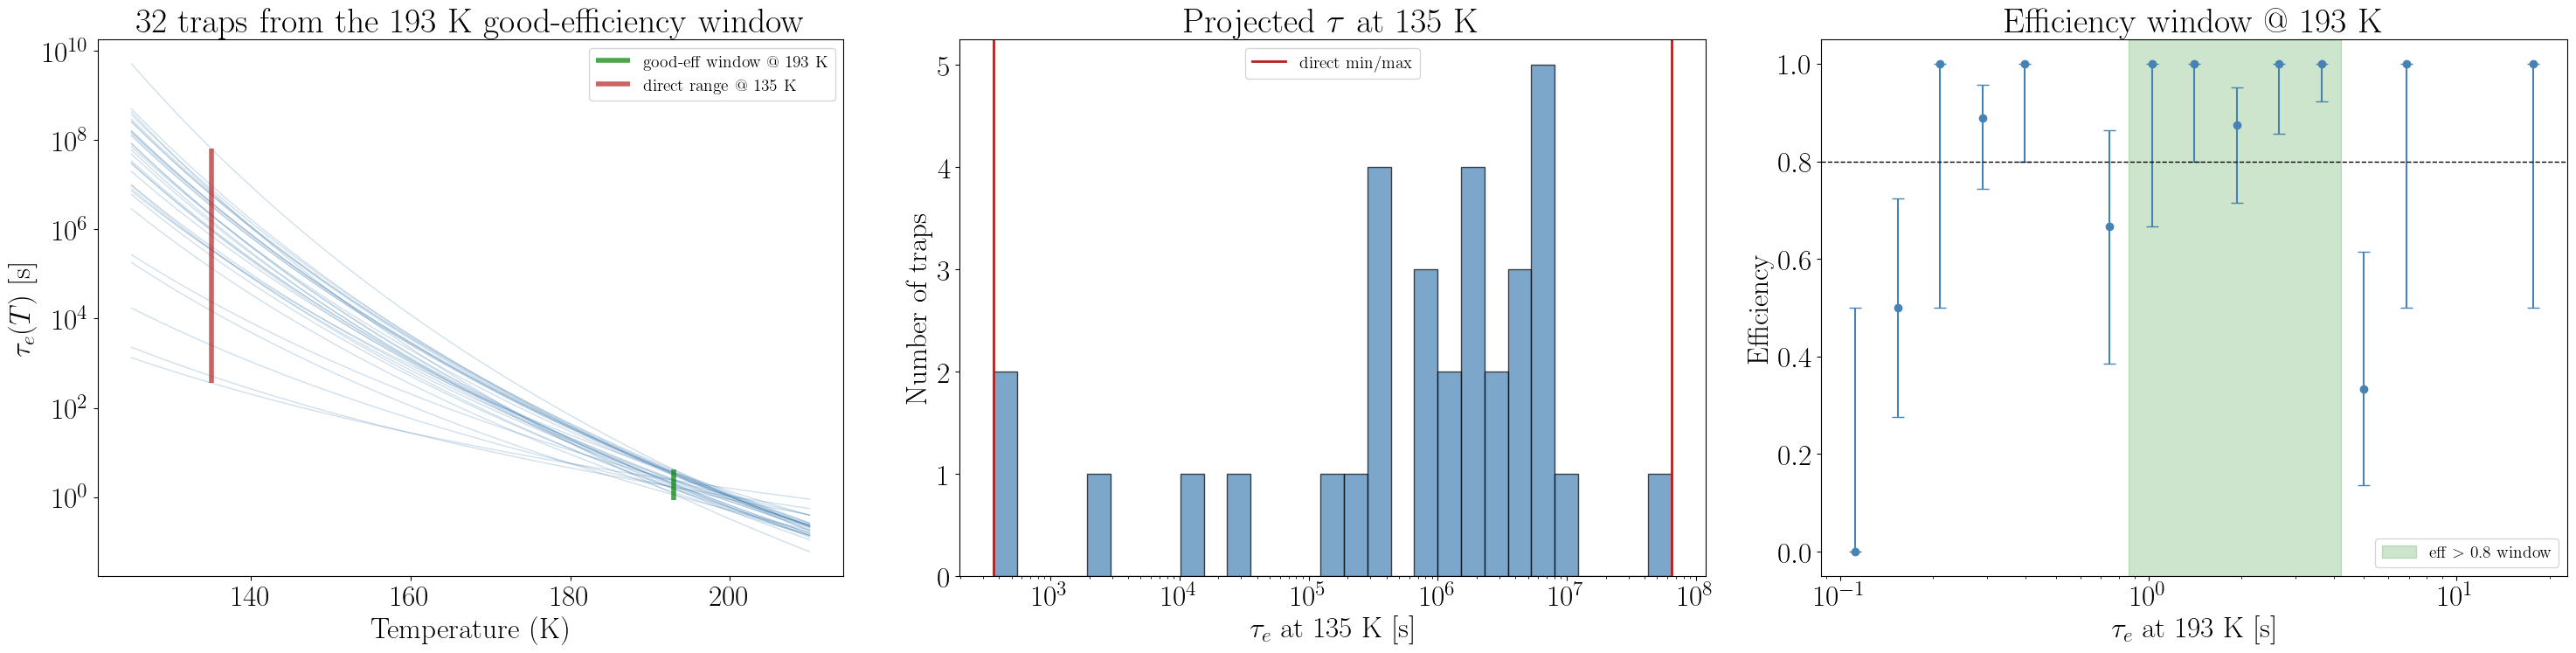

Good-efficiency window at 195 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.3344 s  (2 bins)
  conservative inner edges      : 0.2436 -- 0.2436 s
  traps selected                : 14

Selected-trap parameter ranges:
  E         : 0.3278 -- 0.4035 eV
  log_sigma : -39.0300 -- -34.8030

tau bounds at 135 K (direct per-trap range):
  2123 -- 2.019e+04 s


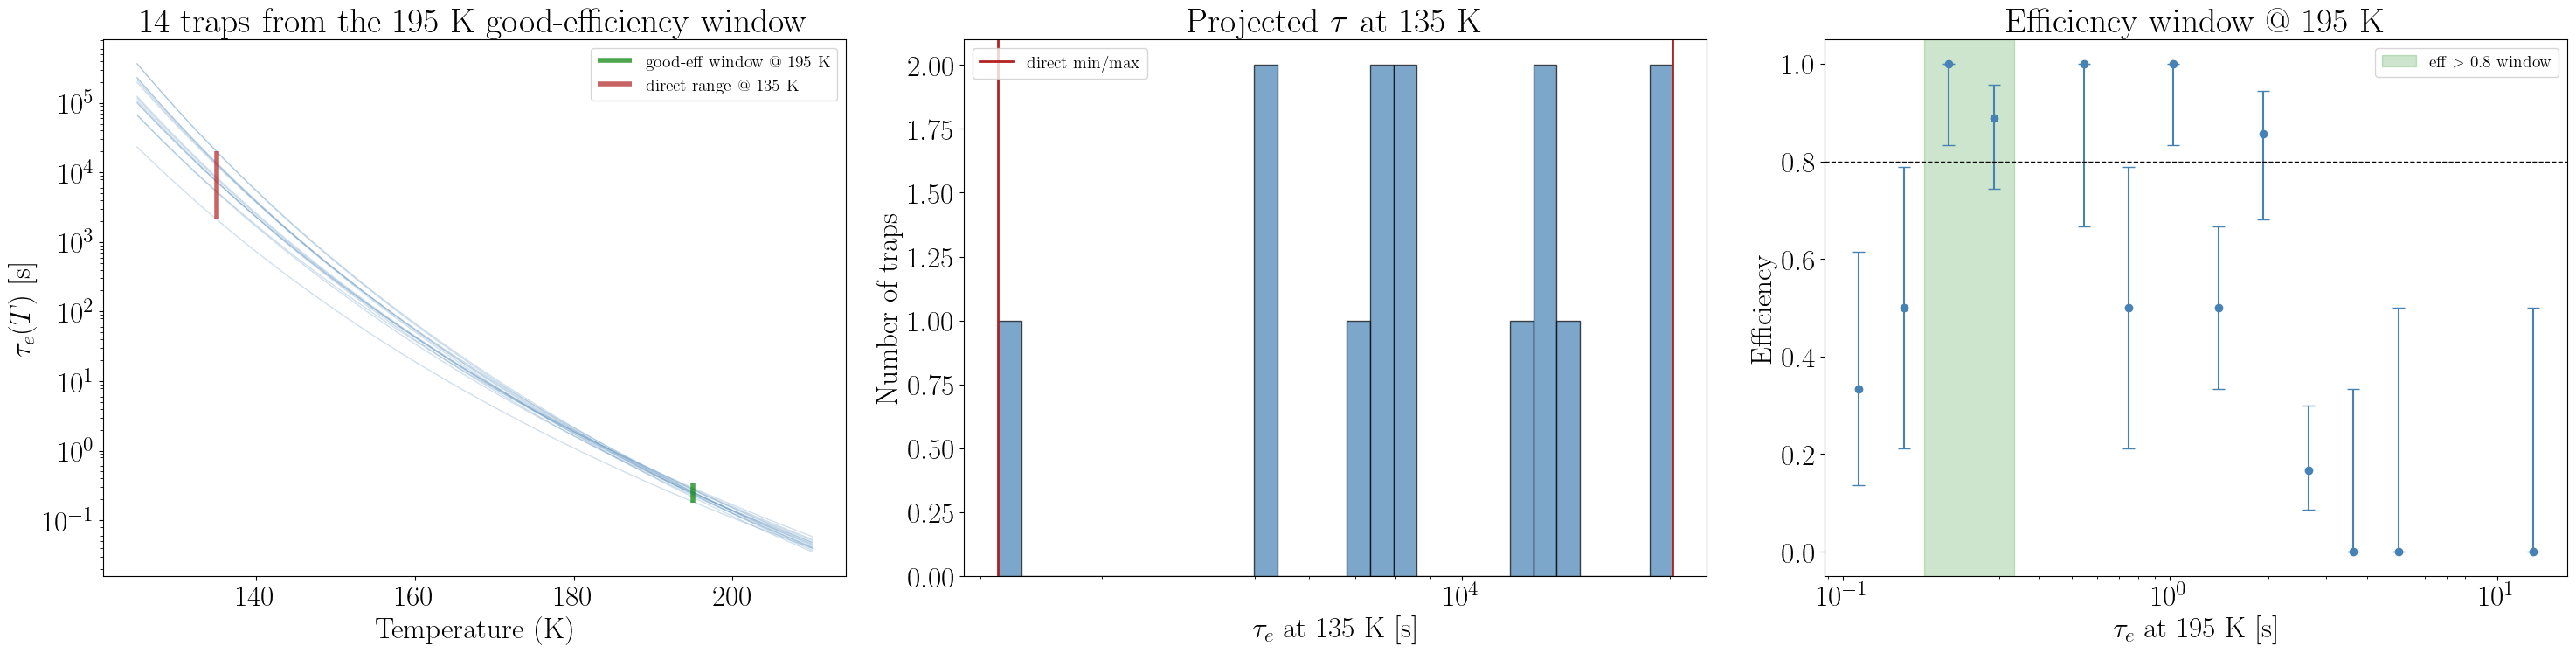

Good-efficiency window at 197 K (eff > 0.8):
  selection range (outer edges) : 0.8647 -- 5.782 s  (6 bins)
  conservative inner edges      : 1.187 -- 4.213 s
  traps selected                : 31

Selected-trap parameter ranges:
  E         : 0.1677 -- 0.6255 eV
  log_sigma : -50.9352 -- -24.1550

tau bounds at 135 K (direct per-trap range):
  361.1 -- 8.153e+07 s


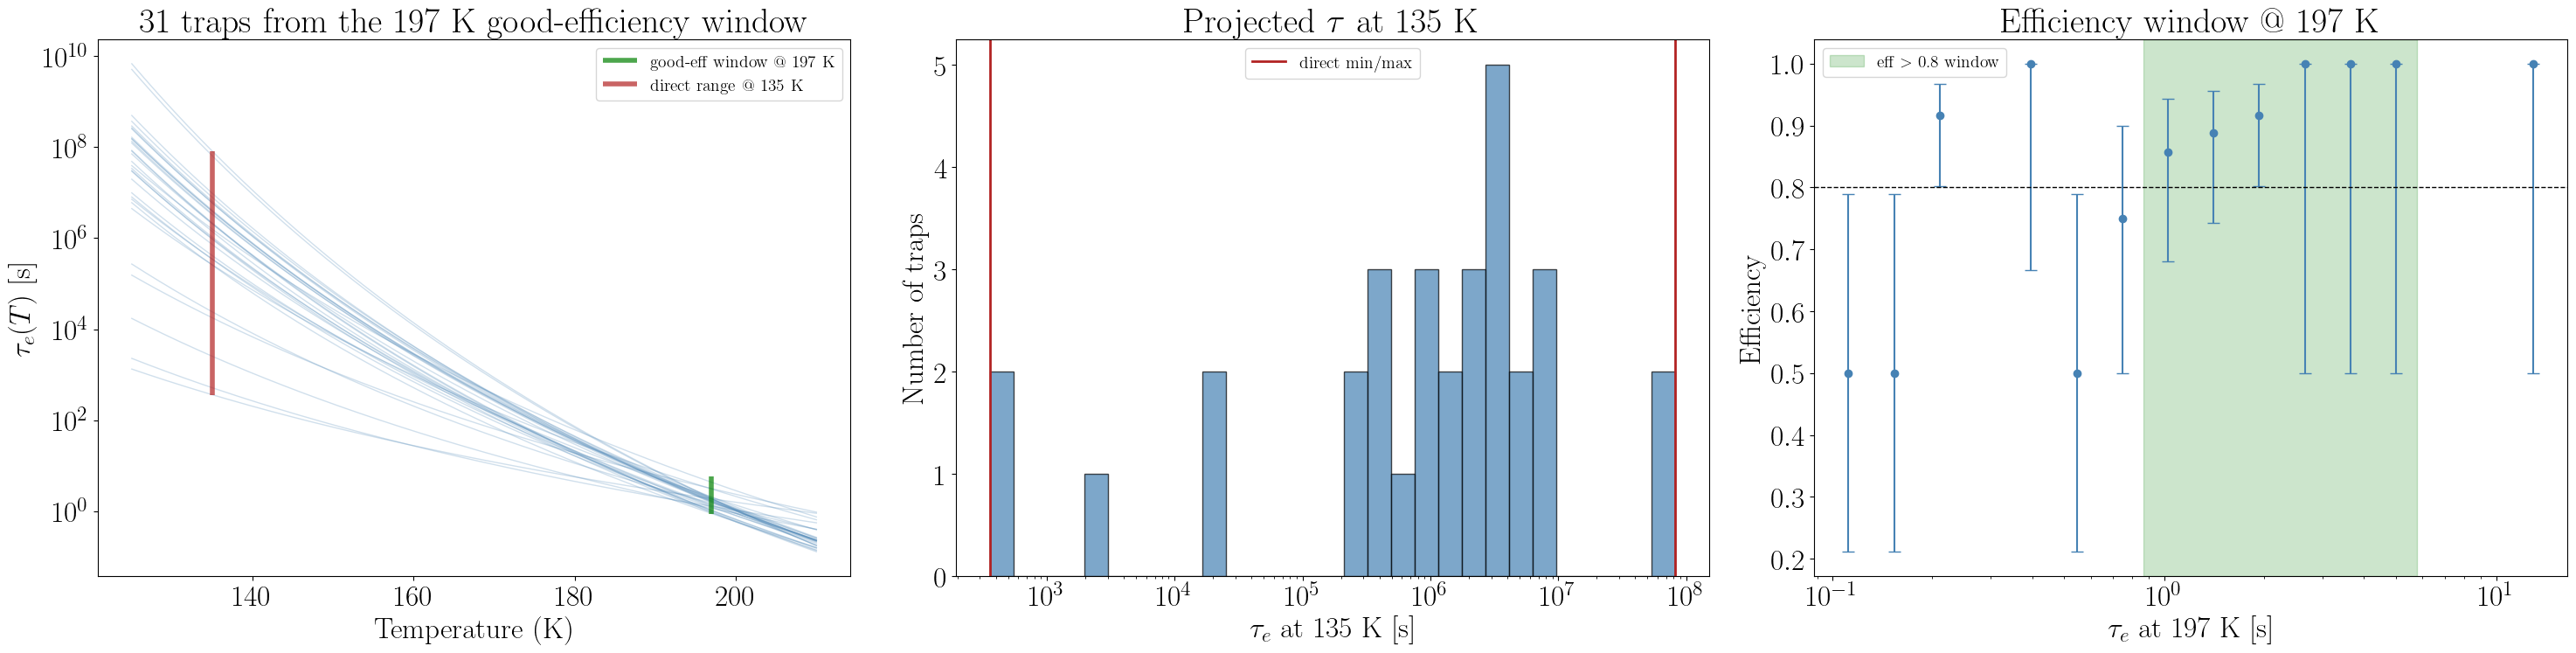

Good-efficiency window at 200 K (eff > 0.8):
  selection range (outer edges) : 0.459 -- 3.069 s  (6 bins)
  conservative inner edges      : 0.63 -- 2.236 s
  traps selected                : 35

Selected-trap parameter ranges:
  E         : 0.1677 -- 0.6255 eV
  log_sigma : -50.9352 -- -24.1550

tau bounds at 135 K (direct per-trap range):
  361.1 -- 8.153e+07 s


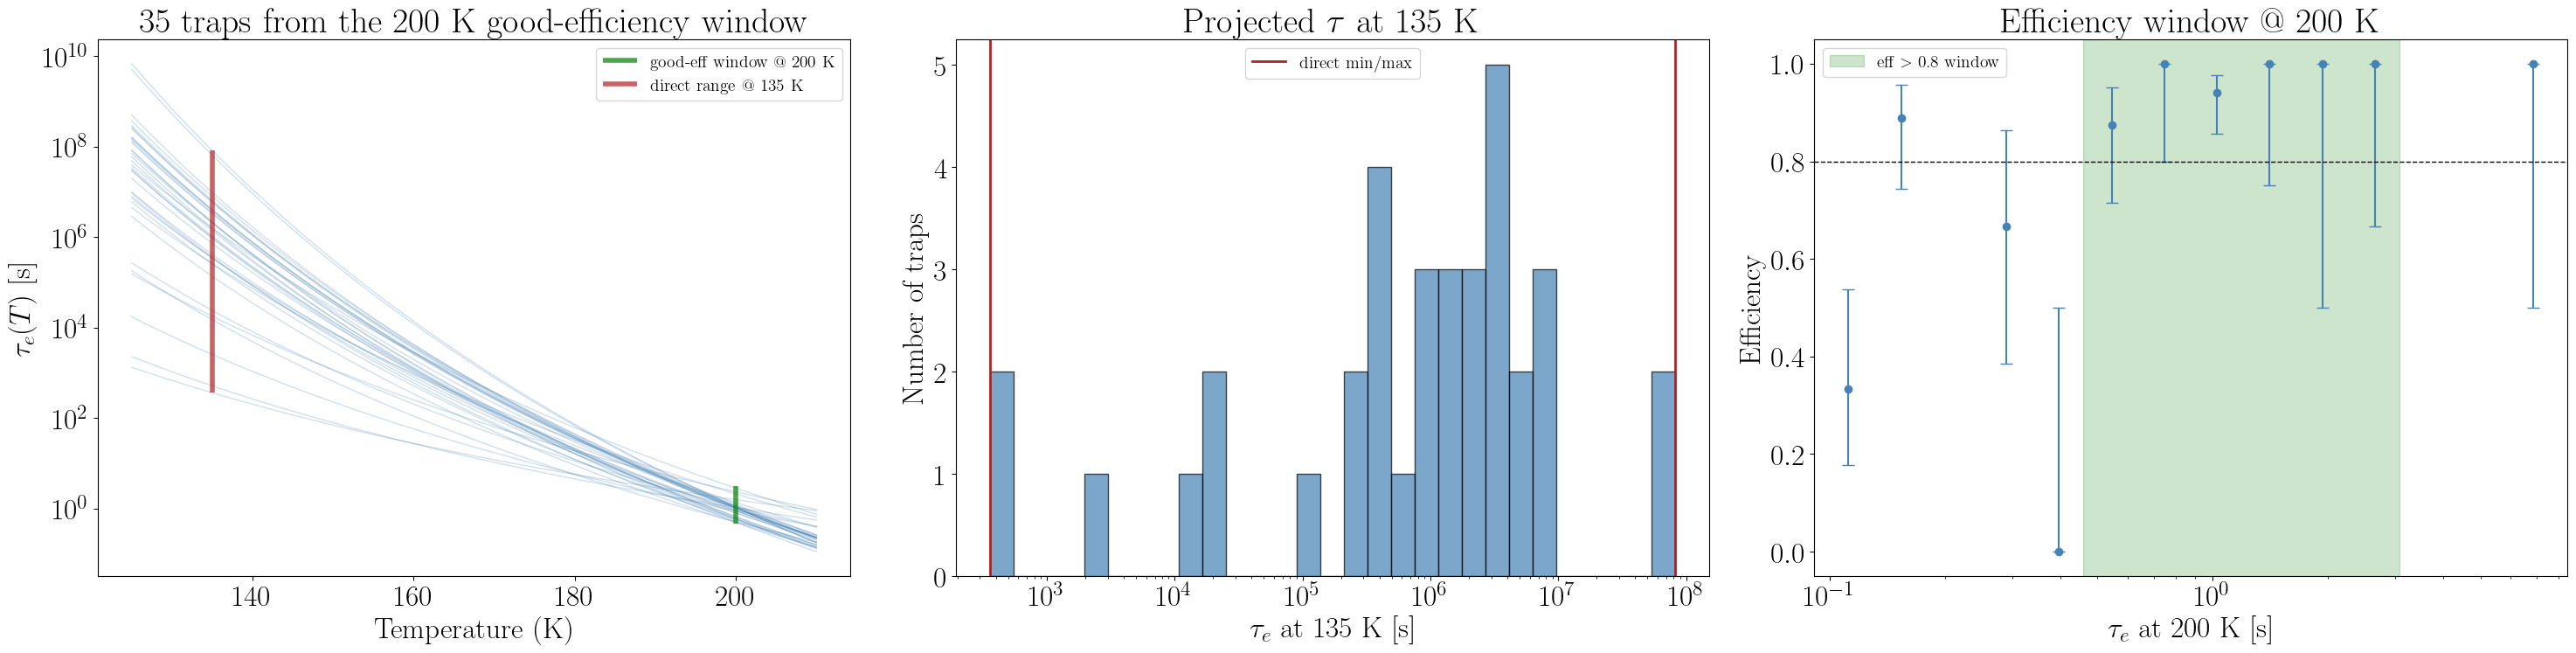

Good-efficiency window at 203 K (eff > 0.8):
  selection range (outer edges) : 0.3344 -- 1.187 s  (4 bins)
  conservative inner edges      : 0.459 -- 0.8647 s
  traps selected                : 29

Selected-trap parameter ranges:
  E         : 0.1951 -- 0.6255 eV
  log_sigma : -48.9512 -- -24.1550

tau bounds at 135 K (direct per-trap range):
  514.3 -- 8.153e+07 s


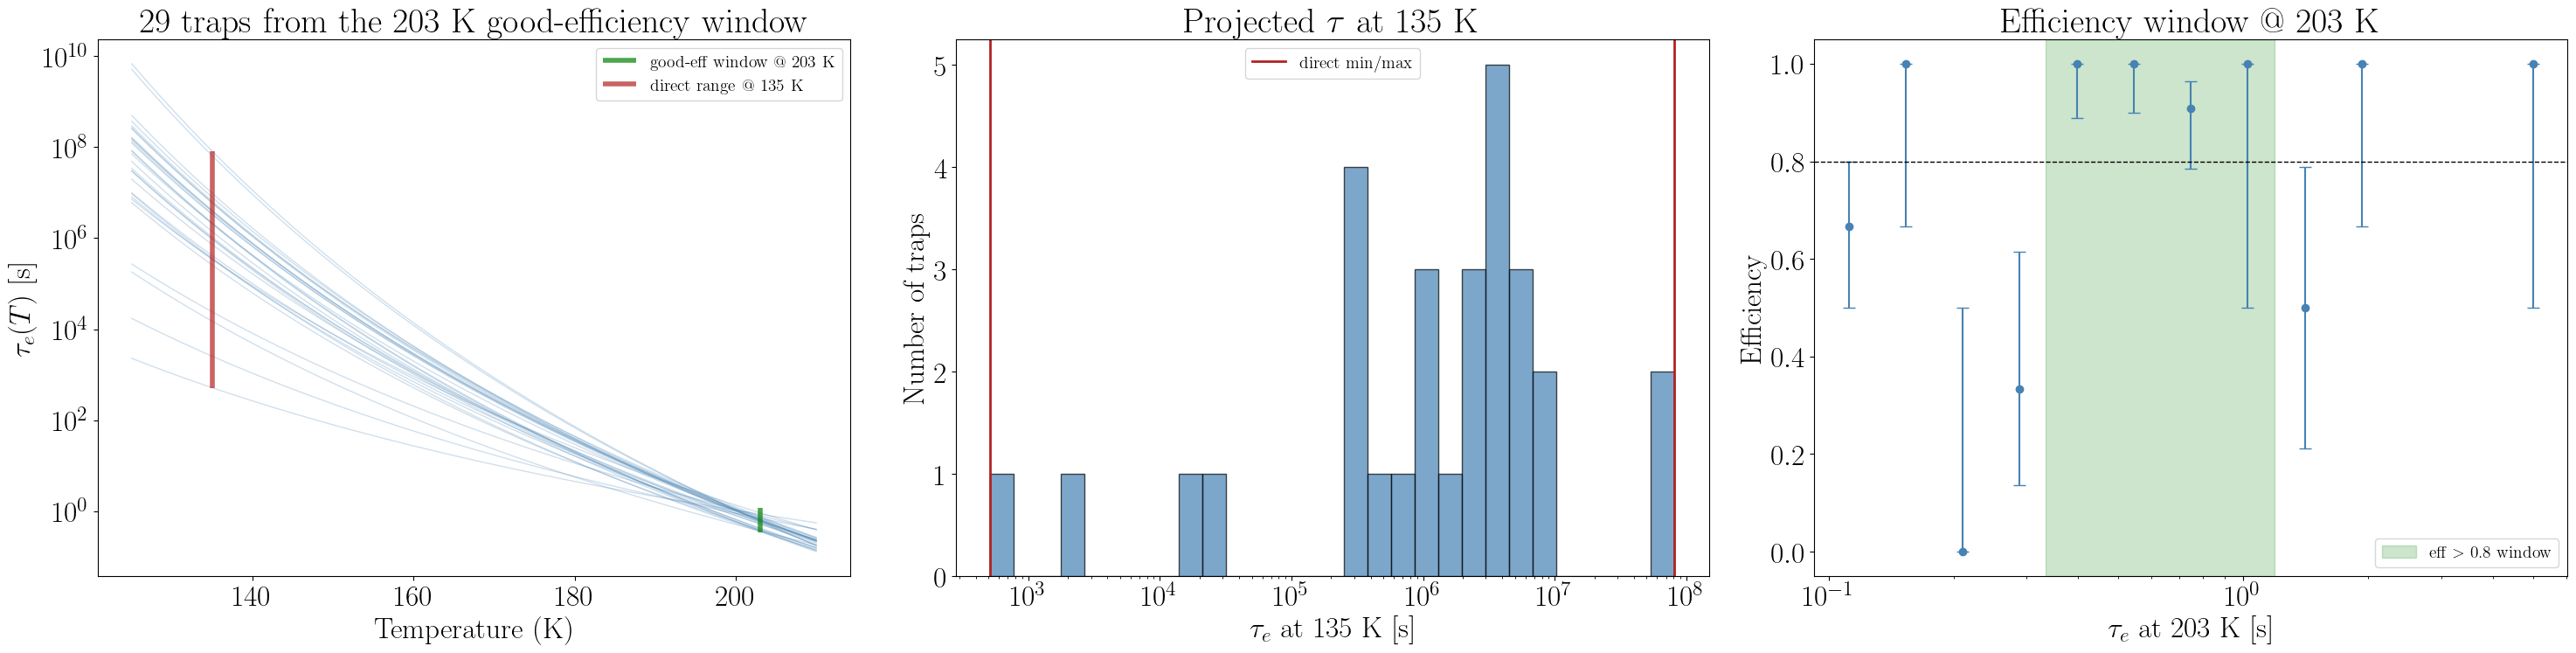

Good-efficiency window at 207 K (eff > 0.8):
  selection range (outer edges) : 0.2436 -- 0.63 s  (3 bins)
  conservative inner edges      : 0.3344 -- 0.459 s
  traps selected                : 20

Selected-trap parameter ranges:
  E         : 0.2581 -- 0.6255 eV
  log_sigma : -45.1655 -- -24.1550

tau bounds at 135 K (direct per-trap range):
  2529 -- 8.153e+07 s


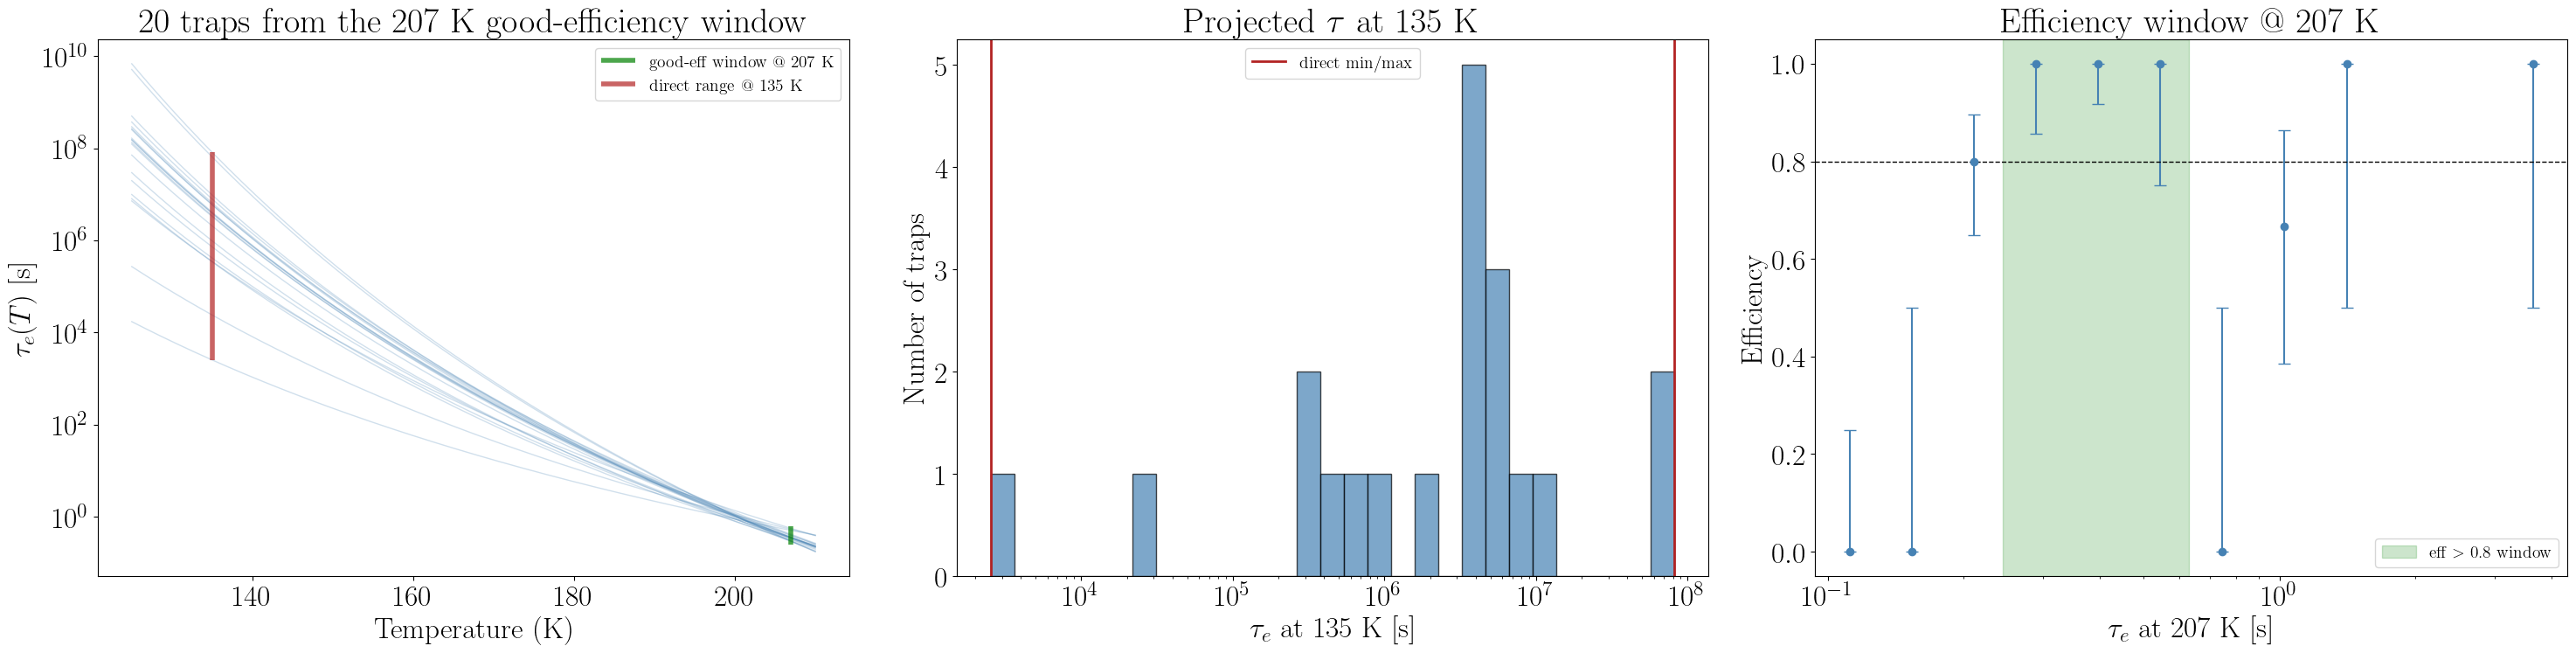

Good-efficiency window at 210 K (eff > 0.8):
  selection range (outer edges) : 0.1775 -- 0.459 s  (3 bins)
  conservative inner edges      : 0.2436 -- 0.3344 s
  traps selected                : 19

Selected-trap parameter ranges:
  E         : 0.2581 -- 0.5544 eV
  log_sigma : -45.1655 -- -28.1007

tau bounds at 135 K (direct per-trap range):
  2529 -- 9.672e+06 s


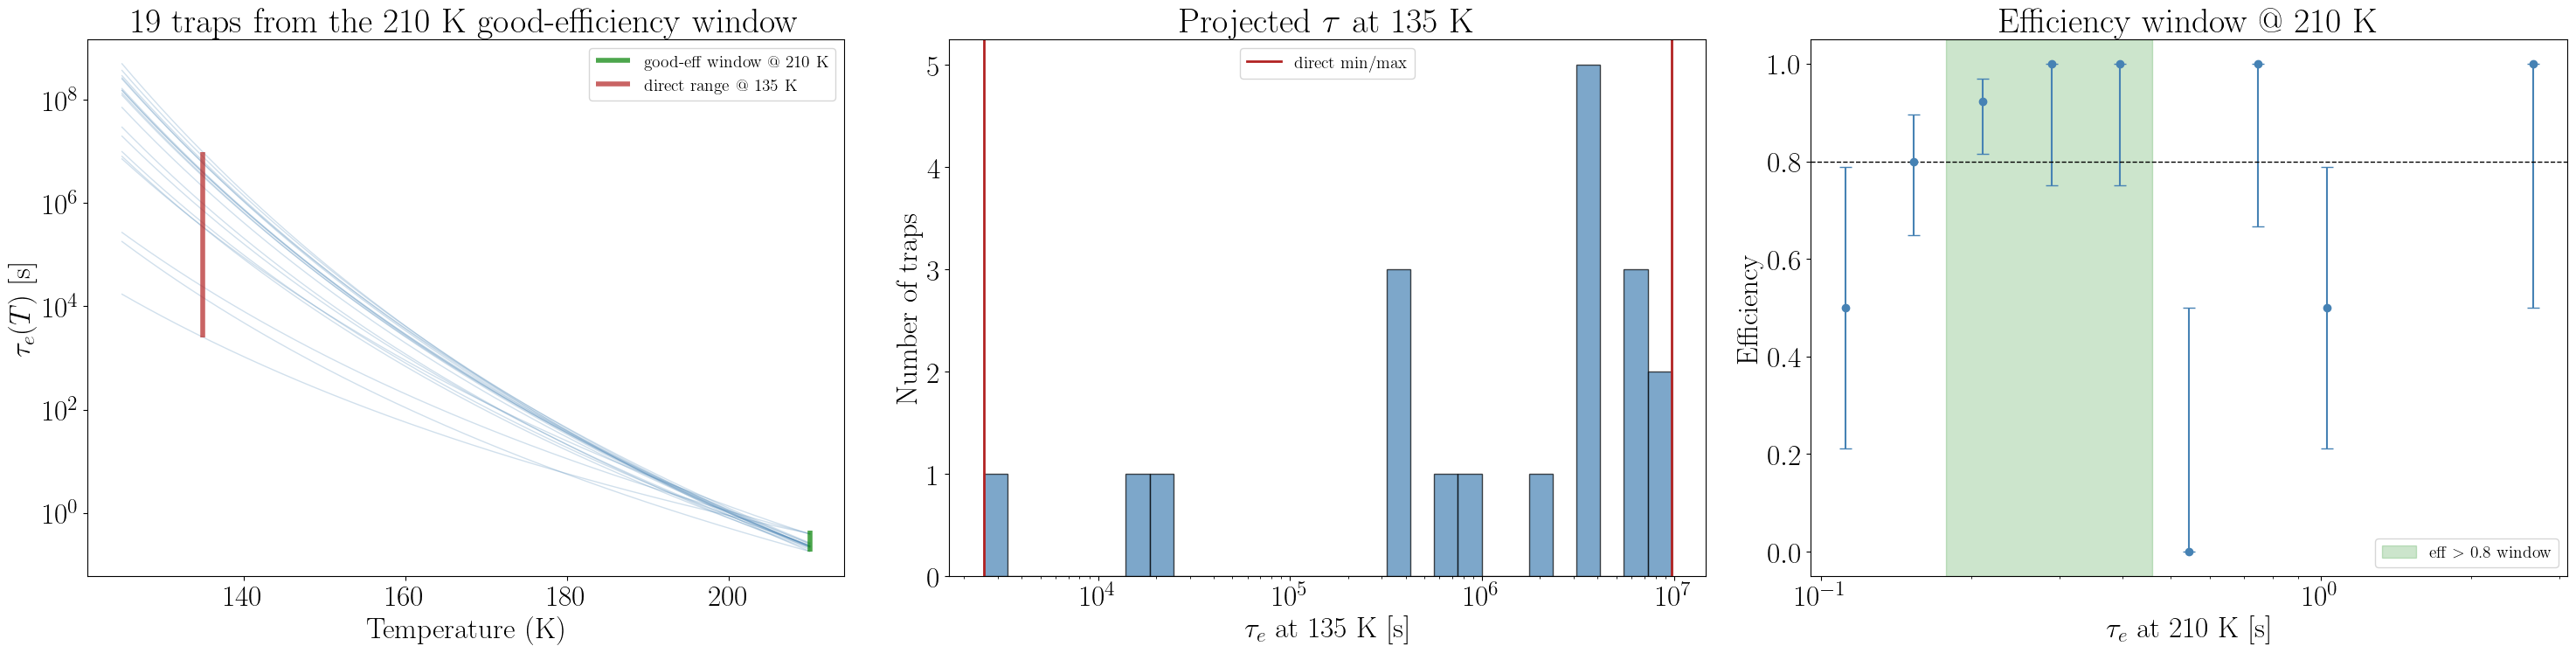

In [ ]:



# ---- knobs (swap records_3 / records_4 / records_1 and the ngood cut here) ----
RECORDS     = records_3      # trap population to select from
NGOOD_CUT   = 4              # require >= this many good temperature fits
EFF_TEMP    = 170          # measurement temperature whose efficiency window we use
THRESHOLD   = 0.8            # efficiency threshold defining the "good" window
TARGET_TEMP = 135.0          # temperature to project the bounds onto
CENTER_MIN  = 1e-1           # ignore bins below this tau (matches the diagnostic above)


def good_efficiency_window(eff_temp, threshold=THRESHOLD, edges=test_bins, center_min=CENTER_MIN):
        """Longest contiguous tau-window at eff_temp where efficiency > threshold.

        Returns a dict with the outer edges (tau_lo, tau_hi) of the qualifying run -- use these
        to *select* traps -- plus the conservative inner edges (inner_lo, inner_hi) for quoting,
        or None if no bin clears the threshold."""
        e = np.where(measurement_temperatures == eff_temp)[0][0]
        eff_hist, _ = all_efficiencies[e]
        centers = (edges[:-1] + edges[1:]) / 2
        cut = centers > center_min
        temp_eff    = eff_hist[cut]
        left_edges  = edges[:-1][cut]
        right_edges = edges[1:][cut]

        run = longest_true_run(temp_eff > threshold)
        if run is None:
            return None
        lo, hi = run
        return {
            'eff_temp': eff_temp,
            'threshold': threshold,
            'n_bins': hi - lo + 1,
            'tau_lo': left_edges[lo],    # outer edges -> trap selection
            'tau_hi': right_edges[hi],
            'inner_lo': right_edges[lo],  # conservative inner edges -> quoting
            'inner_hi': left_edges[hi],
        }


def select_traps_in_window(records, eff_temp, window, ngood_cut=NGOOD_CUT):
    """Characterized traps with >= ngood_cut good fits whose tau(eff_temp) is inside the window."""
    selected = []
    for trap in records:
        if len(trap['measured_temps']) < ngood_cut:
            continue
        tau_T = np.exp(log_energy_cross_section(eff_temp, trap['energy'], trap['log_sigma']))
        if window['tau_lo'] <= tau_T <= window['tau_hi']:
            selected.append(trap)
    return selected


def bounds_at_temp(selected, target_temp=TARGET_TEMP):
    """Direct per-trap tau range at target_temp (min/max over the selected traps)."""
    E    = np.array([t['energy'] for t in selected], dtype=float)
    logS = np.array([t['log_sigma'] for t in selected], dtype=float)
    tau  = np.exp(log_energy_cross_section(target_temp, E, logS))

    return {
        'E': E, 'logS': logS, 'tau': tau,
        'E_min': E.min(), 'E_max': E.max(),
        'logS_min': logS.min(), 'logS_max': logS.max(),
        'tau_min': tau.min(), 'tau_max': tau.max(),
    }


for EFF_TEMP in measurement_temperatures:
    if EFF_TEMP < 140: continue
    
    window = good_efficiency_window(EFF_TEMP, THRESHOLD)
    assert window is not None, f'No bin clears efficiency > {THRESHOLD} at {EFF_TEMP} K'

    selected = select_traps_in_window(RECORDS, EFF_TEMP, window, NGOOD_CUT)
    assert len(selected) > 0, 'No traps fall inside the good-efficiency window'

    b = bounds_at_temp(selected, TARGET_TEMP)

    print(f'Good-efficiency window at {EFF_TEMP} K (eff > {THRESHOLD}):')
    print(f'  selection range (outer edges) : {window["tau_lo"]:.4g} -- {window["tau_hi"]:.4g} s  ({window["n_bins"]} bins)')
    print(f'  conservative inner edges      : {window["inner_lo"]:.4g} -- {window["inner_hi"]:.4g} s')
    print(f'  traps selected                : {len(selected)}')
    print()
    print(f'Selected-trap parameter ranges:')
    print(f'  E         : {b["E_min"]:.4f} -- {b["E_max"]:.4f} eV')
    print(f'  log_sigma : {b["logS_min"]:.4f} -- {b["logS_max"]:.4f}')
    print()
    print(f'tau bounds at {TARGET_TEMP:.0f} K (direct per-trap range):')
    print(f'  {b["tau_min"]:.4g} -- {b["tau_max"]:.4g} s')


    fig, ax = plt.subplots(1, 3, figsize=(30, 8))

    # ---- panel 0: tau(T) for selected traps ----
    Tgrid = np.linspace(measurement_temperatures.min(), measurement_temperatures.max(), 200)
    for t in selected:
        ax[0].plot(Tgrid, np.exp(log_energy_cross_section(Tgrid, t['energy'], t['log_sigma'])),
                color='steelblue', alpha=0.25, lw=1)
    # good-efficiency selection window at EFF_TEMP
    ax[0].vlines(EFF_TEMP, window['tau_lo'], window['tau_hi'], color='green', lw=4, alpha=0.7,
                label=f'good-eff window @ {EFF_TEMP} K')
    # direct per-trap range projected onto TARGET_TEMP
    ax[0].vlines(TARGET_TEMP, b['tau_min'], b['tau_max'], color='firebrick', lw=4, alpha=0.7,
                label=f'direct range @ {TARGET_TEMP:.0f} K')
    ax[0].set_yscale('log')
    ax[0].set_xlabel('Temperature (K)')
    ax[0].set_ylabel(r'$\tau_e(T)$ [s]')
    ax[0].set_title(f'{len(selected)} traps from the {EFF_TEMP} K good-efficiency window')
    ax[0].legend(fontsize=14)

    # ---- panel 1: tau(135K) distribution ----
    hist_bins = np.geomspace(b['tau'].min(), b['tau'].max(), 30)
    ax[1].hist(b['tau'], bins=hist_bins, color='steelblue', edgecolor='black', alpha=0.7)
    ax[1].axvline(b['tau_min'], color='firebrick', lw=2, label='direct min/max')
    ax[1].axvline(b['tau_max'], color='firebrick', lw=2)
    ax[1].set_xscale('log')
    ax[1].set_xlabel(rf'$\tau_e$ at {TARGET_TEMP:.0f} K [s]')
    ax[1].set_ylabel('Number of traps')
    ax[1].set_title(f'Projected $\\tau$ at {TARGET_TEMP:.0f} K')
    ax[1].legend(fontsize=14)

    # ---- panel 2: efficiency vs tau at EFF_TEMP, with the selected window shaded ----
    e = np.where(measurement_temperatures == EFF_TEMP)[0][0]
    eff_hist, eff_yerr = all_efficiencies[e]
    centers = (test_bins[:-1] + test_bins[1:]) / 2
    cut = centers > CENTER_MIN
    ax[2].axvspan(window['tau_lo'], window['tau_hi'], color='green', alpha=0.2,
                label=f'eff $>$ {THRESHOLD} window')
    ax[2].errorbar(centers[cut], eff_hist[cut], yerr=eff_yerr[:, cut],
                marker='o', capsize=5, color='steelblue', ls='None')
    ax[2].axhline(THRESHOLD, ls='--', color='k', lw=1)
    ax[2].set_xscale('log')
    ax[2].set_xlabel(rf'$\tau_e$ at {EFF_TEMP} K [s]')
    ax[2].set_ylabel('Efficiency')
    ax[2].set_title(f'Efficiency window @ {EFF_TEMP} K')
    ax[2].legend(fontsize=14)

    plt.show()
    plt.close()

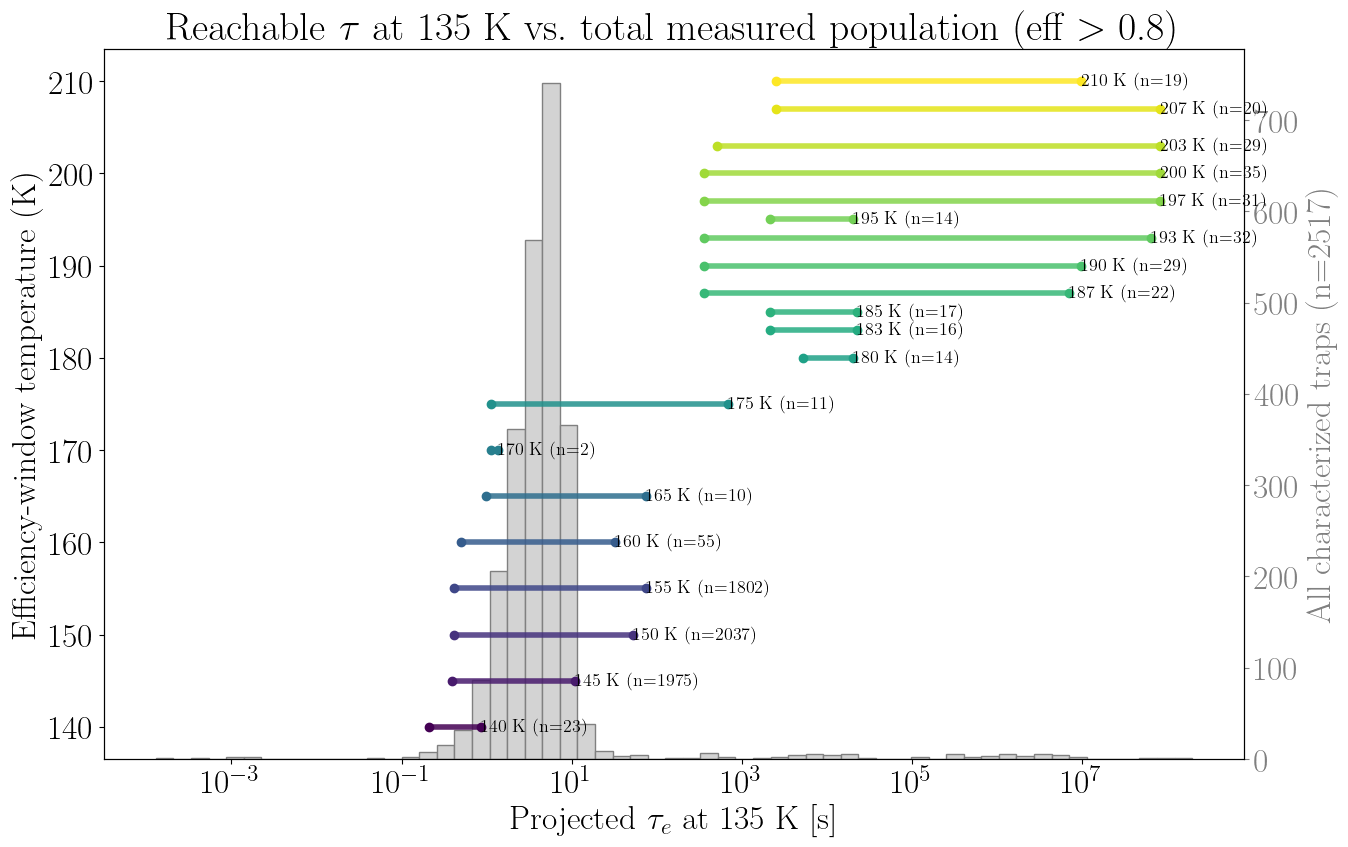

In [14]:
# Scan every efficiency-window temperature >= 140 K and project each good-eff window to TARGET_TEMP.
# Each row shows the direct per-trap tau range at TARGET_TEMP that *that* measurement temperature
# would have let us probe -- i.e. the extent of regions reachable from each temperature.
scan_temps = measurement_temperatures[measurement_temperatures >= 140]

scan = []
for et in scan_temps:
    win = good_efficiency_window(et, THRESHOLD)
    if win is None:
        continue
    sel = select_traps_in_window(RECORDS, et, win, NGOOD_CUT)
    if len(sel) == 0:
        continue
    bb = bounds_at_temp(sel, TARGET_TEMP)
    scan.append({'temp': float(et), 'tau_min': bb['tau_min'], 'tau_max': bb['tau_max'], 'n': len(sel)})

# Total tau_e(TARGET_TEMP) distribution for context: prefer the saved simulation-seed file,
# else rebuild from RECORDS (same WellBehaved + GoodEnergyFit selection as run_charge_traps.py,
# no ngood cut -- matching the saved histogram). This shows the full population the reachable
# ranges are a confident subset of.
try:
    _d = np.load(f'tau_at_{TARGET_TEMP:.0f}k_hist.npz')
    total_tau = _d['tau_at_135s']
except FileNotFoundError:
    total_tau = np.array([r['tau_135'] for r in RECORDS])

hist_edges = np.geomspace(min(total_tau.min(), min(s['tau_min'] for s in scan)),
                          max(total_tau.max(), max(s['tau_max'] for s in scan)), 60)

fig, ax = plt.subplots(figsize=(14, 9))

# background: total tau_e(TARGET_TEMP) histogram on a twin y-axis (shared log x)
ax_h = ax.twinx()
ax_h.hist(total_tau, bins=hist_edges, color='lightgrey', edgecolor='grey', zorder=0)
ax_h.set_ylabel(f'All characterized traps (n={len(total_tau)})', color='grey')
ax_h.tick_params(axis='y', colors='grey')

# foreground: per-temperature reachable ranges
norm_t = colors.Normalize(vmin=min(s['temp'] for s in scan), vmax=max(s['temp'] for s in scan))
for s in scan:
    c = cm.viridis(norm_t(s['temp']))
    ax.hlines(s['temp'], s['tau_min'], s['tau_max'], color=c, lw=4, alpha=0.85)
    ax.plot([s['tau_min'], s['tau_max']], [s['temp'], s['temp']], 'o', color=c)
    ax.text(s['tau_max'], s['temp'], f"  {s['temp']:.0f} K (n={s['n']})", va='center', fontsize=13)

ax.set_zorder(ax_h.get_zorder() + 1)  # ranges in front of the histogram...
ax.patch.set_visible(False)           # ...but let the histogram show through
ax.set_xscale('log')
ax.set_xlabel(rf'Projected $\tau_e$ at {TARGET_TEMP:.0f} K [s]')
ax.set_ylabel('Efficiency-window temperature (K)')
ax.set_title(rf'Reachable $\tau$ at {TARGET_TEMP:.0f} K vs.\ total measured population '
             f'(eff $>$ {THRESHOLD})')
plt.show()

## Robustness diagnostics

Three checks on whether the chosen window / projected range can be trusted:

1. **Counts per bin** — the efficiency is a binomial $k/n$; bins with small $n$ have meaningless
   efficiencies. Overlay $n$ per bin with a minimum-$n$ guide.
2. **Bin & threshold robustness** — re-derive the window and the projected 135 K range under
   varying bin counts, a shifted (phased) bin grid, and thresholds 0.7/0.8/0.9. If the range moves
   little, the choice is defensible; the spread factor quantifies "how much do I depend on the bins."
3. **Cross-temperature overlap** — if the fits + efficiency are self-consistent, neighbouring
   measurement temperatures should project to *overlapping* 135 K ranges. Disagreement flags where
   the efficiency or the E/$\sigma$ extrapolation is unstable.

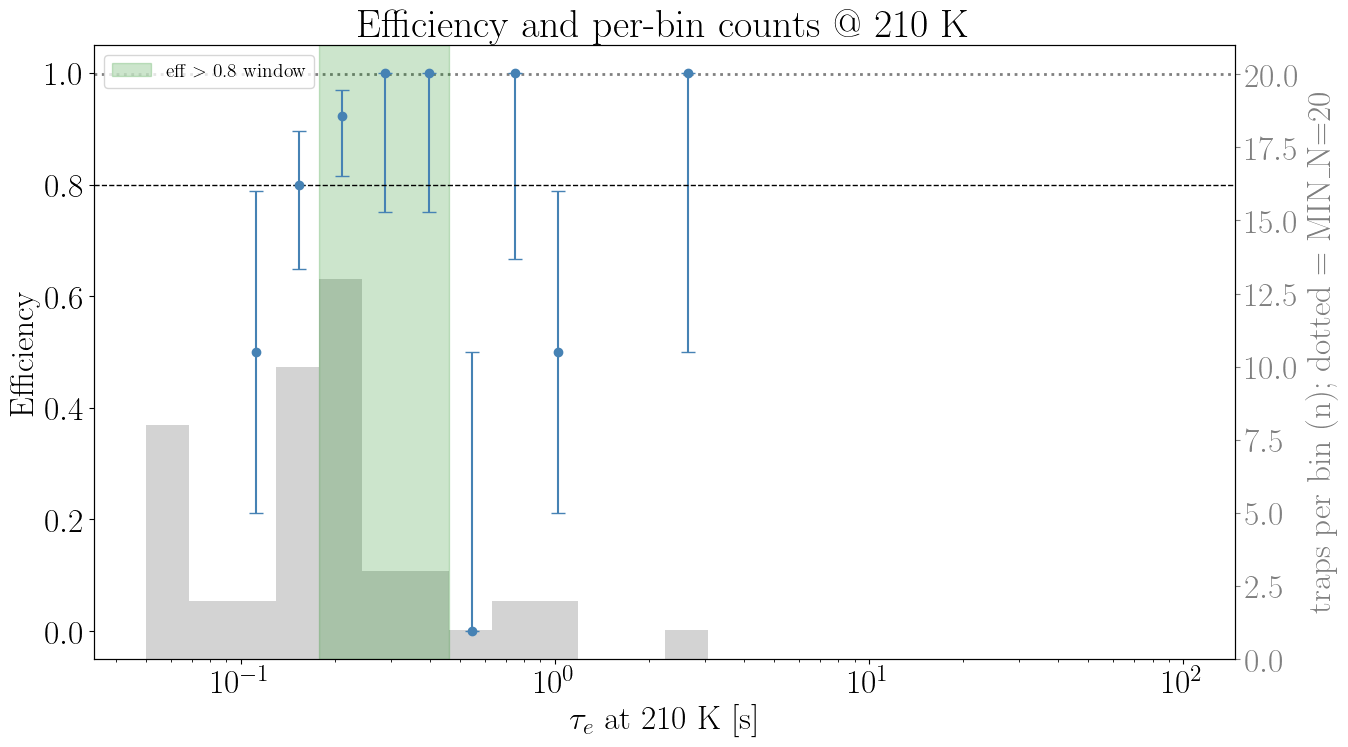

In [19]:
# ---- shared helpers: recompute efficiency for arbitrary binning, find window from a hist ----
def efficiency_at_temp(records, eff_temp, edges, ngood_cut=NGOOD_CUT):
    """measured/extrapolated efficiency histogram at eff_temp for arbitrary bin edges.
    Returns (eff_hist, eff_yerr, n_per_bin). Reuses calc_eff_hist defined above."""
    measured, extrapolated = [], []
    for trap in records:
        if len(trap['measured_temps']) < ngood_cut:
            continue
        tau_T = np.exp(log_energy_cross_section(eff_temp, trap['energy'], trap['log_sigma']))
        if np.any(np.isclose(trap['measured_temps'], eff_temp)):
            measured.append(tau_T)
        else:
            extrapolated.append(tau_T)
    m_hist = np.histogram(measured, bins=edges)[0].astype(float)
    e_hist = np.histogram(extrapolated, bins=edges)[0].astype(float)
    eff_hist, eff_yerr = calc_eff_hist(m_hist, e_hist)
    return eff_hist, eff_yerr, m_hist + e_hist


def window_from_eff(eff_hist, edges, threshold=THRESHOLD, center_min=CENTER_MIN,
                    min_n=0, n_per_bin=None):
    """Longest run of bins (centers > center_min, optionally n >= min_n) with eff > threshold.
    Returns dict with outer edges (tau_lo, tau_hi) or None."""
    centers = (edges[:-1] + edges[1:]) / 2
    cut = centers > center_min
    mask = eff_hist[cut] > threshold
    if min_n and n_per_bin is not None:
        mask = mask & (n_per_bin[cut] >= min_n)
    run = longest_true_run(mask)
    if run is None:
        return None
    lo, hi = run
    le, re = edges[:-1][cut], edges[1:][cut]
    return {'tau_lo': le[lo], 'tau_hi': re[hi], 'n_bins': hi - lo + 1}


# ---- counts-per-bin overlay for the chosen EFF_TEMP / binning ----
MIN_N = 20  # rough binomial-trust guide: Wilson half-width ~0.1 near eff~0.5 needs n~20

eff_hist_c, eff_yerr_c, n_c = efficiency_at_temp(RECORDS, EFF_TEMP, test_bins, NGOOD_CUT)
centers = (test_bins[:-1] + test_bins[1:]) / 2
cut = centers > CENTER_MIN

fig, ax = plt.subplots(figsize=(14, 8))
ax_n = ax.twinx()
ax_n.stairs(n_c, test_bins, fill=True, color='lightgrey', edgecolor='grey', zorder=0)
ax_n.axhline(MIN_N, color='grey', ls=':', lw=2)
ax_n.set_ylabel(f'traps per bin (n);  dotted = MIN\\_N={MIN_N}', color='grey')
ax_n.tick_params(axis='y', colors='grey')

ax.axvspan(window['tau_lo'], window['tau_hi'], color='green', alpha=0.2,
           label=f'eff $>$ {THRESHOLD} window')
ax.errorbar(centers[cut], eff_hist_c[cut], yerr=eff_yerr_c[:, cut], marker='o', capsize=5,
            color='steelblue', ls='None')
ax.axhline(THRESHOLD, ls='--', color='k', lw=1)
ax.set_zorder(ax_n.get_zorder() + 1)  # efficiency in front of the counts...
ax.patch.set_visible(False)           # ...but let the counts show through
ax.set_xscale('log')
ax.set_xlabel(rf'$\tau_e$ at {EFF_TEMP} K [s]')
ax.set_ylabel('Efficiency')
ax.set_title(f'Efficiency and per-bin counts @ {EFF_TEMP} K')
ax.legend(fontsize=14, loc='upper left')
plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\#'
<>:49: SyntaxWarning: invalid escape sequence '\#'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_21760/4037400760.py:49: SyntaxWarning: invalid escape sequence '\#'
  ax.set_ylabel('binning / threshold variation \#')


30 variations succeeded.  Spread of each quantity:
  tau_lo  : median 0.181   range [0.11, 0.255]   x2.31 spread
  tau_hi  : median 0.439   range [0.163, 0.99]   x6.09 spread
  tau_min : median 2.53e+03   range [361, 4.14e+05]   x1145.18 spread
  tau_max : median 7.9e+06   range [2.16e+06, 8.15e+07]   x37.74 spread


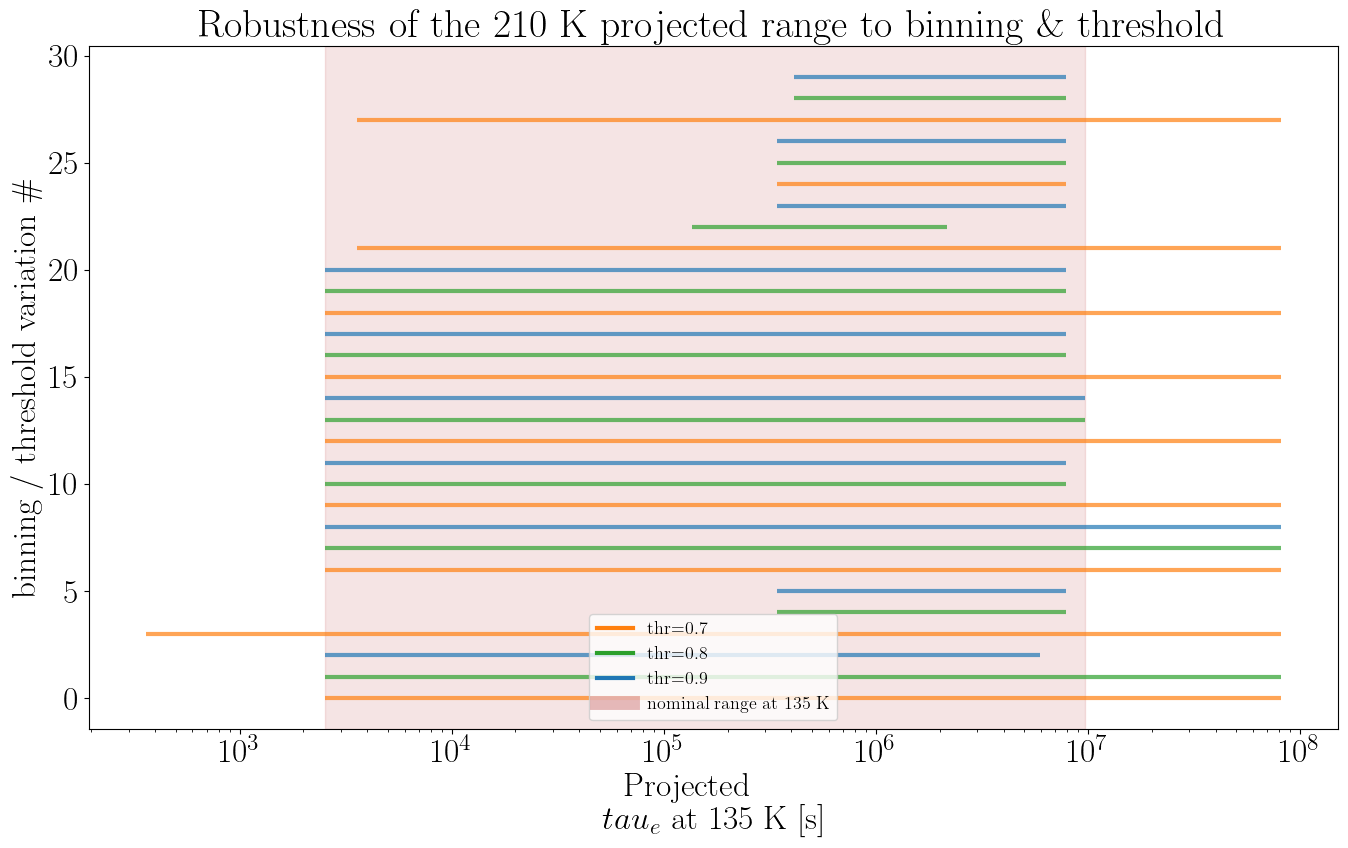

In [22]:
# ---- robustness of the window & projected range to binning and threshold ----
base_lo, base_hi = test_bins.min(), test_bins.max()
nbins_grid     = [15, 20, 25, 30, 40]
phase_grid     = [0.0, 0.5]            # fractional shift of the log-spaced bin grid
threshold_grid = [0.7, 0.8, 0.9]

def make_edges(nbins, phase, lo=base_lo, hi=base_hi):
    log_e = np.linspace(np.log10(lo), np.log10(hi), nbins)
    step = log_e[1] - log_e[0]
    return 10 ** (log_e + phase * step)

rob = []
for nb in nbins_grid:
    for ph in phase_grid:
        edges = make_edges(nb, ph)
        eff_hist_r, _, _ = efficiency_at_temp(RECORDS, EFF_TEMP, edges, NGOOD_CUT)
        for th in threshold_grid:
            win = window_from_eff(eff_hist_r, edges, threshold=th, center_min=CENTER_MIN)
            if win is None:
                continue
            sel = select_traps_in_window(RECORDS, EFF_TEMP, win, NGOOD_CUT)
            if len(sel) == 0:
                continue
            bb = bounds_at_temp(sel, TARGET_TEMP)
            rob.append({'nbins': nb, 'phase': ph, 'threshold': th,
                        'tau_lo': win['tau_lo'], 'tau_hi': win['tau_hi'],
                        'tau_min': bb['tau_min'], 'tau_max': bb['tau_max'], 'n': len(sel)})

# spread is reported geometrically (tau is log-distributed)
print(f'{len(rob)} variations succeeded.  Spread of each quantity:')
for key in ['tau_lo', 'tau_hi', 'tau_min', 'tau_max']:
    lv = np.log10([r[key] for r in rob])
    med, mn, mx = 10**np.median(lv), 10**lv.min(), 10**lv.max()
    print(f'  {key:8s}: median {med:.3g}   range [{mn:.3g}, {mx:.3g}]   x{mx/mn:.2f} spread')

# plot: each variation's projected 135K range, colored by threshold; nominal range shaded
fig, ax = plt.subplots(figsize=(14, 9))
th_colors = {0.7: 'tab:orange', 0.8: 'tab:green', 0.9: 'tab:blue'}
for i, r in enumerate(rob):
    ax.hlines(i, r['tau_min'], r['tau_max'], color=th_colors.get(r['threshold'], 'grey'),
              lw=3, alpha=0.7)
ax.axvspan(b['tau_min'], b['tau_max'], color='firebrick', alpha=0.12)
handles = [Line2D([0], [0], color=c, lw=3, label=f'thr={t}') for t, c in th_colors.items()]
handles.append(Line2D([0], [0], color='firebrick', alpha=0.3, lw=10,
                      label=f'nominal range at {TARGET_TEMP:.0f} K'))
ax.legend(handles=handles, fontsize=13)
ax.set_xscale('log')
ax.set_xlabel(rf'Projected $\\tau_e$ at {TARGET_TEMP:.0f} K [s]')
ax.set_ylabel('binning / threshold variation \#')
ax.set_title(f'Robustness of the {EFF_TEMP} K projected range to binning \\& threshold')
plt.show()

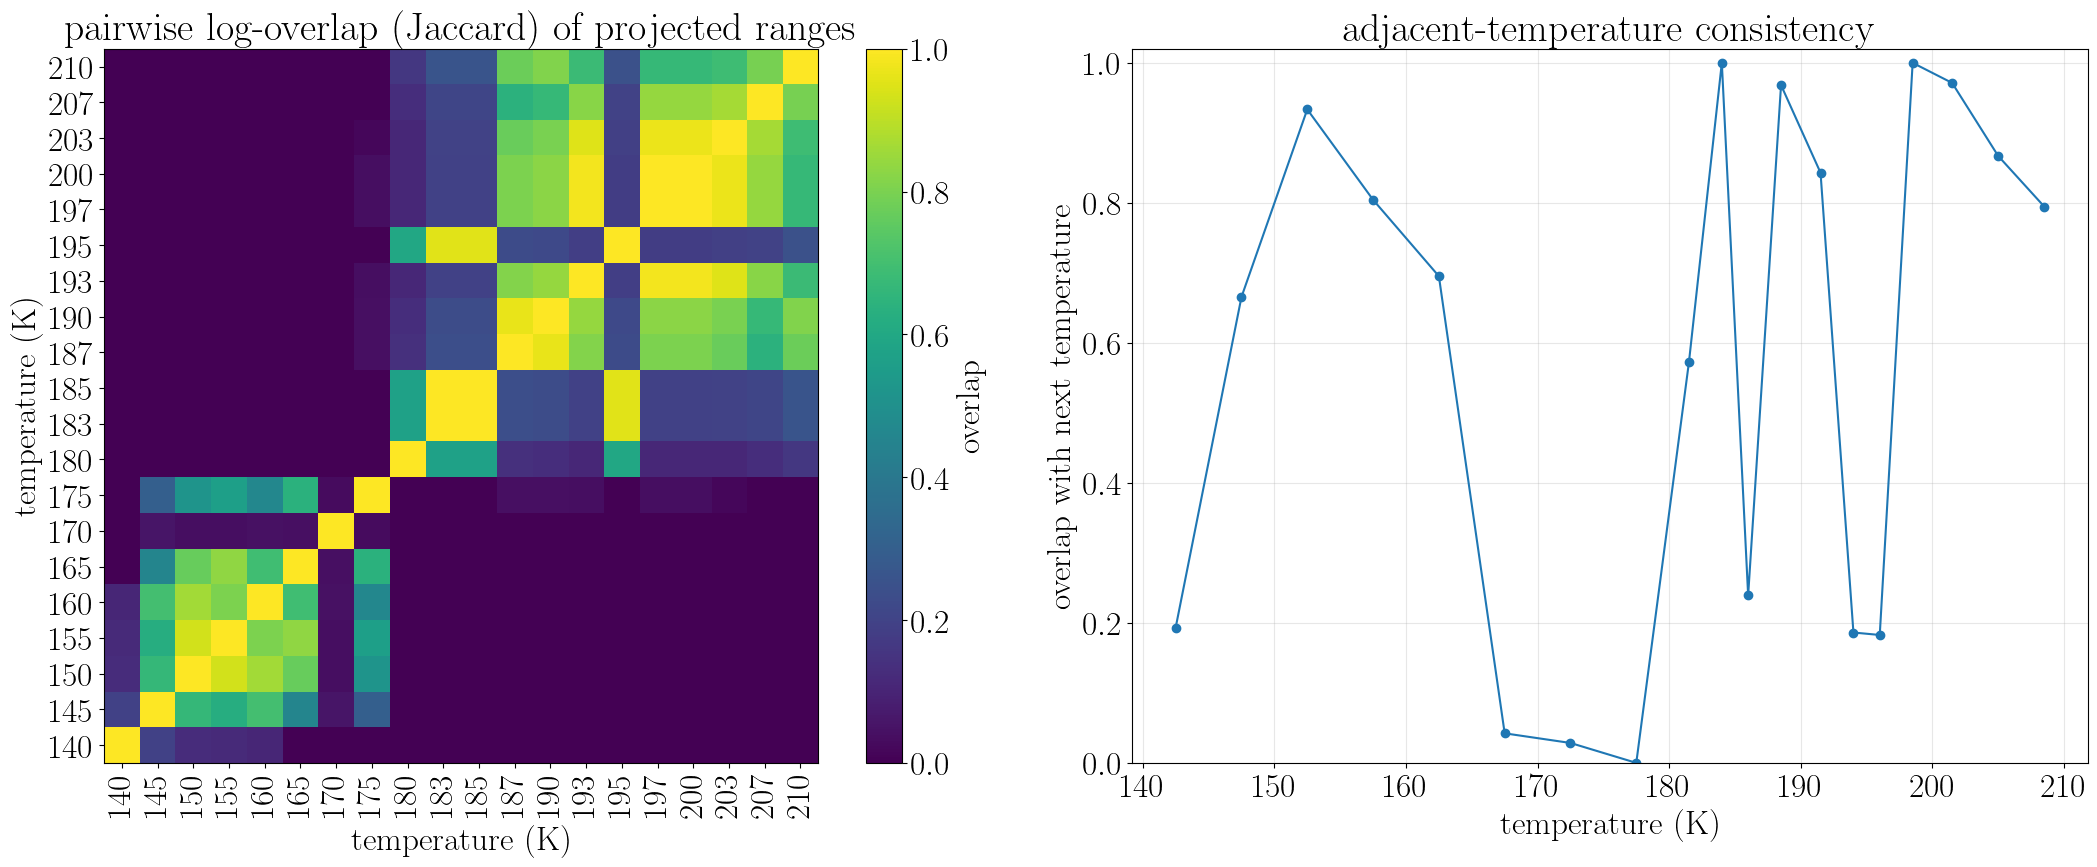

In [21]:
# ---- cross-temperature consistency: do neighbouring projected ranges overlap? ----
# Reuse `scan` from the reachable-range cell above; rebuild it if that cell hasn't run.
try:
    scan
except NameError:
    scan = []
    for et in measurement_temperatures[measurement_temperatures >= 140]:
        win = good_efficiency_window(et, THRESHOLD)
        if win is None:
            continue
        sel = select_traps_in_window(RECORDS, et, win, NGOOD_CUT)
        if len(sel) == 0:
            continue
        bb = bounds_at_temp(sel, TARGET_TEMP)
        scan.append({'temp': float(et), 'tau_min': bb['tau_min'], 'tau_max': bb['tau_max'], 'n': len(sel)})

def log_overlap(r1, r2):
    """Jaccard overlap of two tau intervals in log space (0 = disjoint, 1 = identical)."""
    a1, b1 = np.log10(r1['tau_min']), np.log10(r1['tau_max'])
    a2, b2 = np.log10(r2['tau_min']), np.log10(r2['tau_max'])
    inter = max(0.0, min(b1, b2) - max(a1, a2))
    union = max(b1, b2) - min(a1, a2)
    return inter / union if union > 0 else np.nan

temps = [s['temp'] for s in scan]
M = np.array([[log_overlap(si, sj) for sj in scan] for si in scan])

fig, (axm, axr) = plt.subplots(1, 2, figsize=(22, 9))

im = axm.imshow(M, origin='lower', cmap='viridis', vmin=0, vmax=1,
                extent=[0, len(temps), 0, len(temps)])
axm.set_xticks(np.arange(len(temps)) + 0.5); axm.set_xticklabels([f'{t:.0f}' for t in temps], rotation=90)
axm.set_yticks(np.arange(len(temps)) + 0.5); axm.set_yticklabels([f'{t:.0f}' for t in temps])
axm.set_xlabel('temperature (K)'); axm.set_ylabel('temperature (K)')
axm.set_title('pairwise log-overlap (Jaccard) of projected ranges')
fig.colorbar(im, ax=axm, label='overlap')

# adjacent-temperature overlap as a function of temperature
neigh = [log_overlap(scan[i], scan[i + 1]) for i in range(len(scan) - 1)]
neigh_t = [0.5 * (temps[i] + temps[i + 1]) for i in range(len(scan) - 1)]
axr.plot(neigh_t, neigh, 'o-')
axr.set_ylim(0, 1.02)
axr.set_xlabel('temperature (K)'); axr.set_ylabel('overlap with next temperature')
axr.set_title('adjacent-temperature consistency')
axr.grid(alpha=0.3)
plt.show()

## Could a hidden population have been missed? Cross-temperature band coverage

A trap gets **one detection shot per measurement temperature**: its $\tau(T)$ sweeps across orders
of magnitude over 135--210 K, so the question is not "is efficiency high at $\tau$ at *one* $T$"
but *"does this trap's $\tau(T)$ trajectory enter the detectable band at* **any** *measured $T$?"*
That depends on both $\tau_{135}$ and $E$ (which sets the Arrhenius slope).

For each measured $T>135$ K, define its **detectable band** as the $\tau$ range where the measured
efficiency $\geq 0.5$ (the demonstrated-detection range). Then for a grid of $(\tau_{135}, E)$,
reconstruct $\log\sigma$, walk $\tau(T)$ across all temperatures, and ask whether it lands in any
band. The fraction of the *observed* $E$ range that is covered, as a function of $\tau_{135}$, is
the conservative answer to "is there a blind spot here?".

Band coverage is used rather than an efficiency product $1-\prod_T(1-\mathrm{eff}_T)$ because at
high $T$ only tens of characterized traps exist, so most $\tau$-bins read "0 efficiency" from lack
of *data*, not lack of *sensitivity* -- the product badly under-estimates coverage there. The band
(min/max of populated good bins) is far more stable. **Hard limit:** any trap whose $\tau(T)$ is
outside every band at all $T$ is invisible and cannot be bounded by this method at all.

In [ ]:
# ---- cross-temperature band-coverage: where could a hidden population hide? ----
BAND_EFF  = 0.5    # a temperature "detects" tau in the range where its efficiency >= this
scan_T    = measurement_temperatures[measurement_temperatures > TARGET_TEMP]
band_centers = np.sqrt(test_bins[:-1] * test_bins[1:])

# per-temperature detectable band = [min, max] tau of bins with eff >= BAND_EFF (and centers > CENTER_MIN)
bands = {}
for T in scan_T:
    eff_h, _, _ = efficiency_at_temp(RECORDS, T, test_bins, NGOOD_CUT)
    inb = band_centers[(eff_h >= BAND_EFF) & (band_centers > CENTER_MIN)]
    if inb.size:
        bands[T] = (inb.min(), inb.max())

band_T   = np.array(list(bands.keys()), dtype=float)
band_los = np.array([b[0] for b in bands.values()])
band_his = np.array([b[1] for b in bands.values()])

# observed population
E_obs    = np.array([r['energy'] for r in RECORDS])
t135_obs = np.array([r['tau_135'] for r in RECORDS])
E_lo, E_hi = np.percentile(E_obs, 2), np.percentile(E_obs, 98)

# (tau135, E) grid -> does tau(T) land inside ANY temperature's band?
tau135_grid = np.geomspace(1e-2, 1e6, 160)
E_grid = np.linspace(E_lo, E_hi, 160)
covered = np.zeros((len(E_grid), len(tau135_grid)), dtype=bool)
for i, E in enumerate(E_grid):
    A = log_energy_cross_section(TARGET_TEMP, E, 0.0)   # logtau135 = A - logS  ->  logS = A - log(tau135)
    logS = A - np.log(tau135_grid)
    for j, lS in enumerate(logS):
        tauT = np.exp(log_energy_cross_section(band_T, E, lS))
        covered[i, j] = np.any((tauT >= band_los) & (tauT <= band_his))

cov_frac = covered.mean(axis=0)                       # fraction of observed-E family covered
fully = tau135_grid[cov_frac >= 0.999]
if fully.size:
    print(f'fully covered (100% of observed-E family): tau135 in [{fully.min():.3g}, {fully.max():.3g}] s')
    print(f'observed traps inside that window: '
          f'{np.mean((t135_obs >= fully.min()) & (t135_obs <= fully.max())) * 100:.1f}%')
else:
    print('no fully-covered tau135')

fig, ax = plt.subplots(1, 2, figsize=(24, 9))

# ---- panel 0: blind-spot map over (tau135, E) ----
ax[0].pcolormesh(tau135_grid, E_grid, covered, cmap='Greens', vmin=0, vmax=1.4, shading='auto')
ax[0].scatter(t135_obs, E_obs, s=8, color='firebrick', alpha=0.4, label='observed traps')
ax[0].axvline(1e3, color='k', ls='--', lw=1.5, label=r'$\tau_{135}=10^3$ s')
ax[0].set_xscale('log')
ax[0].set_xlim(tau135_grid.min(), tau135_grid.max())
ax[0].set_xlabel(rf'$\tau_e$ at {TARGET_TEMP:.0f} K [s]')
ax[0].set_ylabel('trap energy E [eV]')
ax[0].set_title('green = caught at some measured T;  white = blind spot')
ax[0].legend(fontsize=13, loc='upper left')

# ---- panel 1: coverage fraction vs tau135, with observed distribution ----
ax_h = ax[1].twinx()
ax_h.hist(t135_obs, bins=np.geomspace(t135_obs.min(), t135_obs.max(), 50),
          color='lightgrey', edgecolor='grey', zorder=0)
ax_h.set_ylabel('observed traps', color='grey'); ax_h.tick_params(axis='y', colors='grey')

ax[1].plot(tau135_grid, cov_frac, color='seagreen', lw=3)
if fully.size:
    ax[1].axvspan(fully.min(), fully.max(), color='seagreen', alpha=0.12, label='100% covered')
ax[1].axvline(1e3, color='k', ls='--', lw=1.5)
ax[1].set_zorder(ax_h.get_zorder() + 1); ax[1].patch.set_visible(False)
ax[1].set_xscale('log')
ax[1].set_ylim(0, 1.02)
ax[1].set_xlabel(rf'$\tau_e$ at {TARGET_TEMP:.0f} K [s]')
ax[1].set_ylabel('fraction of observed-E family covered', color='seagreen')
ax[1].set_title('coverage vs projected $\\tau$  (grey = where your traps actually are)')
ax[1].legend(fontsize=13, loc='center left')
plt.show()